In [6]:
import torch
import torchvision

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F

In [15]:
# Define the mapping of rules to trend direction (medical logic; only positive/negative direction needs to be specified, no numerical values required)
RULE_TRENDS = {
    0: "positive",   # Rule 0 (Advanced age) → Increased risk (positive correlation)
    1: "positive",   # Rule 1 (Smoking) → Increased risk (positive)
    2: "positive",   # Rule 2 (Shortness of breath) → Increased risk (positive correlation)
    3: "positive",   # Rule 3 (Biofuels) → Increased risk (positive)
    4: "negative",   # Rule 4 (Low COPD-SQ) → Risk reduction (negative)
    5: "positive",   # Rule 5 (Cough) → Increased risk (positive)
    6: "positive",   # Rule 6 (Enlarged, swollen tongue) → Increased risk (positive correlation)
    7: "positive",   # Rule 7 (White mossy coating) → Increased risk (positive correlation)
    8: "positive"    # Rule 8 (Scalloped tongue) → Increased risk (positive association)
}

# -----------------------
# 2) Rule-Guided COPD Model
# -----------------------
class COPDMultiModel_RuleGuided(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, modal_slices, rule_feat_dim=0,
                 n_heads=4, n_layers=1, dropout=0.2):
        super().__init__()
        self.modal_slices = modal_slices
        self.modal_names = list(modal_slices.keys())
        self.hidden_dim = hidden_dim
        self.n_mods = len(self.modal_names)
        self.num_heads = n_heads
        self.output_dim = output_dim

        # per-modal encoder：
        self.modal_encoders = nn.ModuleDict({
            m: nn.Sequential(
                nn.LayerNorm(end - start),  
                nn.Linear(end - start, hidden_dim),
                nn.ReLU(),  
                nn.LayerNorm(hidden_dim),  
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim)  
            )
            for m, (start, end) in modal_slices.items()
        })

        # cross-modal transformer：
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            batch_first=True,
            norm_first=True,  
            dropout=dropout,
            layer_norm_eps=1e-4,
            bias=True,
            activation="relu"  
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
       
        self.attention_fusion = nn.MultiheadAttention(
            embed_dim=hidden_dim, 
            num_heads=n_heads,  #
            batch_first=True,
            dropout=dropout
        )
       
        self.modal_prior_fuse = nn.Sequential(
            nn.LayerNorm(hidden_dim*2 ),
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )
      
        # 3. Rules + Trends → Sample-level classification priors (Core: predicting the classification tendency of samples)
        self.rule_trend_prior = nn.Sequential(
            nn.LayerNorm(rule_feat_dim*2 ),  # 
            nn.Linear(rule_feat_dim*2, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
        )

        
        # Branch 1: Fusion branch → hidden_dim (used for attention-based fusion to maintain performance)
        self.rule_trend_fusion = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )

        # Branch 2: Loss branch → output_dim (for KL loss calculation, rule-guided)
        self.rule_trend_loss = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim), 
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=1)  # 
        )
 
        # final classifier：
        self.fusion_classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),  
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim//2),
            nn.Linear(hidden_dim//2, output_dim)
        )

    def forward(self, x, feature_slices, copd_b, device):
        rule_feats, trend_feats = get_rule_truths2(x, feature_slices, copd_b, device)

        tokens = []
        for m in self.modal_names:
            start, end = self.modal_slices[m]
            xm = x[:, start:end]
            emb = self.modal_encoders[m](xm)
            tokens.append(emb)
        tokens = torch.stack(tokens, dim=1)  # [B, M, H]

        fused_modal = self.transformer(tokens)  # [B, M, H]
        fused_modal_vec = fused_modal.mean(dim=1)  # [B, H]：
    
        if rule_feats is not None and trend_feats is not None:
            # Concatenating Rule-based and Trend-based Features
            rule_trend_feat = torch.cat([rule_feats, trend_feats], dim=1)  # [B, 18]
            check_nan("rule_trend_feat", rule_trend_feat)
            
            # 2. Shared layer extracts core features
            shared_feat = self.rule_trend_prior(rule_trend_feat)  # [B, H]
            
            # 3. Branch 1: Fusion Prior (hidden_dim, used for attention-based fusion)
            sample_prior_fusion = self.rule_trend_fusion(shared_feat)  # [B, H]
            
            # 4. Branch 2: Loss using prior (output_dim, for KL loss)
            sample_prior = self.rule_trend_loss(shared_feat)  # [B, output_dim]
            check_nan("sample_prior_loss", sample_prior)
        
       
        modal_feat = fused_modal_vec.unsqueeze(1)  # [B, 1, hidden_dim]
        prior_feat = sample_prior_fusion.unsqueeze(1)  # [B, 1, hidden_dim]
        
        # Attention computation: Modal features serve as queries, classification priors serve as keys and values, and fusion weights are learned.
        fusion_feat, attn_weights = self.attention_fusion(
            query=prior_feat,
            key=modal_feat,
            value=modal_feat
        )
        fusion_feat = fusion_feat.squeeze(1)  # [B, hidden_dim]

        fusion_feat = torch.cat([fused_modal_vec, fusion_feat], dim=1)  # [B, 2H] #fused_modal_vec + fusion_feat  #
        fusion_feat = self.modal_prior_fuse(fusion_feat)                        # [B, H]

        logits = self.fusion_classifier(fusion_feat)
        check_nan("final_logits", logits)
        
        return logits, sample_prior 

def check_nan(name, tensor, rule_feats=None):
    if torch.isnan(tensor).any():
        print(f"❌ NaN found in {name}, tensor {tensor},  value {rule_feats}")
    if torch.isinf(tensor).any():
        print(f"❌ Inf found in {name}")


In [16]:
舌色_labels = ['淡红舌', '淡白舌', '枯白舌', '红舌', '舌尖红', '舌边尖红', '暗红舌', '紫红舌', '绛舌', '淡紫舌', '紫暗舌', '绛紫舌', '瘀点舌', '瘀斑舌', '青紫']
舌形_labels = ['正常', '胖舌', '瘦舌', '老舌', '嫩舌', '肿胀舌', '齿痕舌', '点刺舌', '裂纹舌']
舌态_labels = ['正常', '歪斜', '强硬', '短缩', '萎软', '颤动']
苔质_labels = ['薄苔', '厚苔', '腻苔', '腐苔', '偏苔', '剥落苔', '地图舌', '镜面舌', '花剥苔', '类剥苔', '润苔', '滑苔', '燥苔', '糙苔']
苔色_labels = ['白苔', '黄白相兼苔', '黄苔', '浅黄苔', '深黄苔', '焦黄苔', '灰黑苔']
舌下脉络_labels = ['正常', '短而细，色淡', '粗胀，色青紫', '脉络曲张，青紫色较淡', '脉络曲张超过舌下脉的1/2，青紫色重']

面色_labels = ['面红黄隐隐明润含蓄', '面色淡白', '面色苍白', '面色晄白', '面色淡黄', '面色萎黄', '面色黄而鲜明', '面色黄而晦暗', '面色淡青', '面色青灰', 
             '面色青黄', '面色青紫', '面色通红', '面色暗红', '面色黑而黯淡', '面色黑而干焦', '面色黧黑', '面色略晦暗', '面色晦暗']
唇色_labels = ['红润', '淡白', '暗红', '赤肿', '青黑', '青紫', '口唇颜色暗', '口唇颜色暗,并且散在（瘀点）瘀斑']
局部特征_labels = ['无', '两颧潮红', '眼眶周围暗黑']
面部光泽_labels = ['少量光泽', '有光泽', '无光泽']

体质_labels = ['平和质', '阳虚质', '痰湿质', '湿热质', '气虚质', '阴虚质', '血瘀质', '特禀质', '气郁质', '基本是平和质', '血瘀质体质倾向',
             '阳虚质体质倾向', '湿热质体质倾向', '气虚质体质倾向', '痰湿质体质倾向', '气郁质体质倾向', '阴虚质体质倾向']

肺功能_labels = ['肺通气功能正常', '轻度通气功能障碍', '中度通气功能障碍', '重度通气功能障碍', ]

label_zh2en = {
 
    "constitution": {
        "平和质" : "Balanced constitution",
        "阳虚质" : "Yang-deficiency constitution",
        "痰湿质" : "Phlegm-dampness constitution",
        "湿热质" : "Dampness-heat constitution",
        "气虚质" : "Qi-deficiency constitution",
        "阴虚质" : "Yin-deficiency constitution",
        "血瘀质" : "Blood-stasis constitution",
        "特禀质" : "Special diathesis constitution",
        "气郁质" : "Qi-depression constitution",
        "基本是平和质" : "Predominantly balanced constitution",
        "血瘀质体质倾向" : "Tendency toward blood-stasis constitution",
        "阳虚质体质倾向" : "Tendency toward yang-deficiency constitution",
        "湿热质体质倾向" : "Tendency toward dampness-heat constitution",
        "气虚质体质倾向" : "Tendency toward qi-deficiency constitution",
        "痰湿质体质倾向" : "Tendency toward phlegm-dampness constitution",
        "气郁质体质倾向" : "Tendency toward qi-depression constitution",
        "阴虚质体质倾向" : "Tendency toward yin-deficiency constitution"
    },
    "tongueColor": {
        "淡红舌": "Light red tongue",
        "淡白舌": "Pale tongue",
        "枯白舌": "Withered pale tongue",
        "红舌": "Red tongue",
        "舌尖红": "Red tip of tongue",
        "舌边尖红": "Red edges and tip of tongue",
        "暗红舌": "Dark red tongue",
        "紫红舌": "Purplish red tongue",
        "绛舌": "Crimson tongue",
        "淡紫舌": "Light purple tongue",
        "紫暗舌": "Purple-dark tongue",
        "绛紫舌": "Crimson-purple tongue",
        "瘀点舌": "Tongue with petechiae",
        "瘀斑舌": "Tongue with ecchymosis",
        "青紫": "Blue-purple Tongue"
    },
    
    "tongueShape": {
        "正常": "Normal",
        "胖舌": "Enlarged tongue",
        "瘦舌": "Thin tongue",
        "老舌": "Tough tongue",
        "嫩舌": "Tender tongue",
        "肿胀舌": "Edematous tongue",
        "齿痕舌": "Tongue with teeth marks",
        "点刺舌": "Tongue with spots or thorns",
        "裂纹舌": "Tongue with cracks"
    },

    "tongueCondition": {
        "正常": "Normal",
        "歪斜": "Deviated",
        "强硬": "Stiff",
        "短缩": "Shortened",
        "萎软": "Flaccid",
        "颤动": "Trembling"
    },
    
    "coatingTexture": {
        "薄苔": "Thin coating",
        "厚苔": "Thick coating",
        "腻苔": "Greasy coating",
        "腐苔": "Rotten coating",
        "偏苔": "Asymmetric coating",
        "剥落苔": "Peeled coating",
        "地图舌": "Geographic tongue",
        "镜面舌": "Mirror tongue",
        "花剥苔": "Patchy desquamated coating",
        "类剥苔": "Quasi-desquamated coating",
        "润苔": "Moist coating",
        "滑苔": "Slippery coating",
        "燥苔": "Dry coating",
        "糙苔": "Rough coating"
    },

    "coatingColor": {
        "白苔": "White coating",
        "黄白相兼苔": "Mixed yellow and white coating",
        "黄苔": "Yellow coating",
        "浅黄苔": "Light yellow coating",
        "深黄苔": "Dark yellow coating",
        "焦黄苔": "Scorched yellow coating",
        "灰黑苔": "Grey-black coating"
    },

    "faceColor": {
        "面红黄隐隐明润含蓄": "Subtly reddish-yellow, bright and moist complexion",
        "面色淡白": "Pale complexion",
        "面色苍白": "Pallid complexion",
        "面色晄白": "Pale and shiny complexion",
        "面色淡黄": "Light yellow complexion",
        "面色萎黄": "Sallow and dull complexion",
        "面色黄而鲜明": "Bright yellow complexion",
        "面色黄而晦暗": "Dull yellow complexion",
        "面色淡青" : "Light cyan complexion",
        "面色青灰" : "Bluish-gray complexion",
        "面色青黄": "Cyan-yellow complexion",
        "面色青紫": "Cyan-purple complexion",
        "面色通红": "Bright red complexion",
        "面色暗红": "Dark red complexion",
        "面色黑而黯淡" : "Dull black complexion",
        "面色黑而干焦" : "Dry scorched black complexion",
        "面色黧黑" : "Dark brown complexion",
        "面色略晦暗" : "Slightly dull complexion",
        "面色晦暗" : "Dull complexion"
    },

    "lipColor": {
        "红润": "Ruddy",
        "淡白": "Pale",
        "暗红": "Dark red",
        "赤肿": "Red and swollen",
        "青黑": "Cyan-black",
        "青紫": "Cyan-purple",
        "口唇颜色暗": "Dark lip color",
        "口唇颜色暗,并且散在（瘀点）瘀斑": "Dark lip color with scattered petechiae/ecchymosis"
    },

    # 局部特征
    "localFeature": {
        "无": "Normal",
        "两颧潮红": "Flushed cheekbones",
        "眼眶周围暗黑": "Dark black around the orbits"
    },

    "faceGloss": {
        "少量光泽": "Slight luster",
        "有光泽": "Lustrous",
        "无光泽": "Dull"
    },

    
}


le_舌色 = LabelEncoder()
le_舌色.fit(舌色_labels)
舌色_mapping = dict(zip(舌色_labels, range(len(舌色_labels))))

le_舌形 = LabelEncoder()
le_舌形.fit(舌形_labels)
舌形_mapping = dict(zip(舌形_labels, range(len(舌形_labels))))

le_舌态 = LabelEncoder()
le_舌态.fit(舌态_labels)
舌态_mapping = dict(zip(舌态_labels, range(len(舌态_labels))))

le_苔质 = LabelEncoder()
le_苔质.fit(苔质_labels)
苔质_mapping = dict(zip(苔质_labels, range(len(苔质_labels))))

le_苔色 = LabelEncoder()
le_苔色.fit(苔色_labels)
苔色_mapping = dict(zip(苔色_labels, range(len(苔色_labels))))

le_舌下脉络 = LabelEncoder()
le_舌下脉络.fit(舌下脉络_labels)
舌下脉络_mapping = dict(zip(舌下脉络_labels, range(len(舌下脉络_labels))))

le_面色 = LabelEncoder()
le_面色.fit(面色_labels)
面色_mapping = dict(zip(面色_labels, range(len(面色_labels))))

le_唇色 = LabelEncoder()
le_唇色.fit(唇色_labels)
唇色_mapping = dict(zip(唇色_labels, range(len(唇色_labels))))

le_局部特征 = LabelEncoder()
le_局部特征.fit(局部特征_labels)
局部特征_mapping = dict(zip(局部特征_labels, range(len(局部特征_labels))))

le_面部光泽 = LabelEncoder()
le_面部光泽.fit(面部光泽_labels)
面部光泽_mapping = dict(zip(面部光泽_labels, range(len(面部光泽_labels))))

le_体质 = LabelEncoder()
le_体质.fit(体质_labels)
体质_mapping = dict(zip(体质_labels, range(len(体质_labels))))

le_肺功能 = LabelEncoder()
le_肺功能.fit(肺功能_labels)
肺功能_mapping = dict(zip(肺功能_labels, range(len(肺功能_labels))))

print("肺功能_mapping ", 肺功能_mapping)

def encode_labels(value, mapping, isNoSplit = False):
    if isNoSplit :
        encoded = [mapping[value]]
    else :
        value_str = str(value).replace("，", ",")
        labels = [v.strip() for v in value_str.split(",")]        
        encoded = [mapping[label] for label in labels]
    return sum(2 ** i for i in encoded)

def decode_labels(encoded_value, mapping):
    decoded_labels = []
    for label, code in mapping.items():
        if encoded_value & (2 ** code): 
            decoded_labels.append(label)
    return decoded_labels

def decode_multihot(vec, mapping, threshold=0.5):
    if isinstance(vec, torch.Tensor):
        vec = vec.detach().cpu().numpy()

    decoded = []
    for label, idx in mapping.items():
        if idx < len(vec) and vec[idx] > threshold:
            decoded.append(label)
    return decoded

def multi_hot_encode(value, mapping, is_no_split=False):
    num_classes = len(mapping)
    vec = np.zeros(num_classes, dtype=np.float32)

    if pd.isna(value) or str(value).strip() == "":
        return vec

    if is_no_split:
        labels = [str(value).strip()]
    else:
        value_str = str(value).replace("，", ",")
        labels = [v.strip() for v in value_str.split(",")]

    for lab in labels:
        if lab in mapping:
            idx = mapping[lab]
            vec[idx] = 1.0
        else:
            print(f"[multi_hot_encode] 未知标签: {lab}")
    return vec

class MultimodalDataset(Dataset):
    def __init__(self, data_file, image_dir, transform=None):
        self.df = pd.read_excel(data_file) 
        self.image_dir = image_dir
        self.transform = transform

        self.df['最终诊断意见'] = self.df['最终诊断意见'].apply(lambda x: -1 if pd.isna(x) or str(x).strip() == '' or str(x).strip() == 'nan' else 肺功能_mapping[x]) 


    def __len__(self):
        return len(self.df)

    def safe_str(self, value):
        return value if pd.notna(value) else " "

    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
    
            #生理数据
            spo2 = row['血氧']
            rr = row['呼吸率']
   
            # ----------- 生理(连续)特征：性别、年龄、BMI -----------
            gender = self.to_numeric(row['性别'])
            age = self.to_numeric(row['age'])
            bmi = self.to_numeric(row['bmi'])
    
            #生活习惯
            smokingHistory = self.safe_str(row['吸烟指数'])
            FHRD = row['呼吸疾病家族史']
            biofuelsHistory = row['生物燃料接触史']
            shortnessOfBreath = row['是否气促']
            cough = row['咳嗽']

            copdSQ =  row['COPD-SQ得分']
            constitution = row['主体质']

            #舌面
            faceColor = row['面色']
            lipColor = row['唇色']
            localFeat = row['局部特征']
            faceGloss = row['面部光泽']

            tongueColor = row['舌色']
            tongueShape = row['舌形']
            tongueCondition = row['舌态']
            coatingTexture = row['苔质']
            coatingColor = row['苔色']

            isCopd = row['最终诊断意见']

            constitution_vec = multi_hot_encode(constitution, 体质_mapping)
            faceColor_vec = multi_hot_encode(faceColor, 面色_mapping)
            lipColor_vec = multi_hot_encode(lipColor, 唇色_mapping, is_no_split=True)
            localFeat_vec = multi_hot_encode(localFeat, 局部特征_mapping)
            faceGloss_vec = multi_hot_encode(faceGloss, 面部光泽_mapping)

            tongueColor_vec = multi_hot_encode(tongueColor, 舌色_mapping)
            tongueShape_vec = multi_hot_encode(tongueShape, 舌形_mapping)
            tongueCondition_vec = multi_hot_encode(tongueCondition, 舌态_mapping)
            coatingTexture_vec = multi_hot_encode(coatingTexture, 苔质_mapping)
            coatingColor_vec = multi_hot_encode(coatingColor, 苔色_mapping)
           
            result = {
                'gender': torch.tensor([gender], dtype=torch.float32),
                'age': torch.tensor([age], dtype=torch.float32),
                'BMI': torch.tensor([bmi], dtype=torch.float32),
                
                'smokingHistory': torch.tensor([smokingHistory], dtype=torch.float32),
                'FHRD': torch.tensor([FHRD], dtype=torch.float32),
                'biofuelsHistory': torch.tensor([biofuelsHistory], dtype=torch.float32),
                'shortnessOfBreath': torch.tensor([shortnessOfBreath], dtype=torch.float32),
                'cough': torch.tensor([cough], dtype=torch.float32),
                'copdSQ': torch.tensor([copdSQ], dtype=torch.float32),
                'constitution': torch.tensor(constitution_vec, dtype=torch.float32),
                'faceColor': torch.tensor(faceColor_vec, dtype=torch.float32),
                'lipColor': torch.tensor(lipColor_vec, dtype=torch.float32),
                'localFeat': torch.tensor(localFeat_vec, dtype=torch.float32),
                'faceGloss': torch.tensor(faceGloss_vec, dtype=torch.float32),

                'tongueColor': torch.tensor(tongueColor_vec, dtype=torch.float32),
                'tongueShape': torch.tensor(tongueShape_vec, dtype=torch.float32),
                'tongueCondition': torch.tensor(tongueCondition_vec, dtype=torch.float32),
                'coatingTexture': torch.tensor(coatingTexture_vec, dtype=torch.float32),
                'coatingColor': torch.tensor(coatingColor_vec, dtype=torch.float32),

                'isCopd': torch.tensor(isCopd, dtype=torch.long),
            }
    
            return result
        except Exception as e:
            print(f"\n❌ 错误发生在 idx={idx}")
            print(self.df.iloc[idx])  
            raise e


    def to_numeric(self, value):
        if pd.isna(value):  
            return 0.0
        if isinstance(value, str):
            value = value.strip().replace('%', '').replace('mmHg', '').replace('次/分', '').replace('/', '').replace('kg', '')
            try:
                return float(value)  
            except ValueError:
                return 0.0  
        return float(value)  

肺功能_mapping  {'肺通气功能正常': 0, '轻度通气功能障碍': 1, '中度通气功能障碍': 2, '重度通气功能障碍': 3}


In [17]:
dataset = MultimodalDataset(r"D:\code\data\copd_patient\copd_tcm_out.xlsx", r"D:\workdir\中医\中医诊断\数据集\COPD\汇总数据\image")
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)  
test_size = dataset_size - train_size 
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [18]:
# Basic and Rule Define
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import torch
import ltn
import torch
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold

categorical_features = ["faceColor", "constitution", "tongueColor", "tongueShape", "coatingTexture"]
feature_mappings = {
    "faceColor": 面色_mapping,
    "constitution": 体质_mapping,
    "tongueColor": 舌色_mapping,
    "tongueShape": 舌形_mapping,
    "coatingTexture": 苔质_mapping, 
}
feature_names = [
    "gender", "age",  "BMI", "smokingHistory", "FHRD", "biofuelsHistory", "shortnessOfBreath", 'cough', #"COPD-SQ Score",#
    "constitution", "faceColor", "lipColor", "localFeat", "faceGloss", "tongueColor", "tongueShape", 'tongueCondition', "coatingTexture", "coatingColor"
]

feature_dims = {
    "gender": 1,
    "age": 1,
    "BMI": 1,
    "smokingHistory": 1,
    "FHRD": 1,
    "biofuelsHistory": 1,
    "shortnessOfBreath": 1,
    "cough": 1,
    "copdSQ": 1,

    "constitution": len(体质_labels),
    "faceColor": len(面色_labels),
    "lipColor": len(唇色_labels),
    "localFeat": len(局部特征_labels),
    "faceGloss": len(面部光泽_labels),

    "tongueColor": len(舌色_labels),
    "tongueShape": len(舌形_labels),
    "tongueCondition": len(舌态_labels),
    "coatingTexture": len(苔质_labels),
    "coatingColor": len(苔色_labels),
}

class CopdClass(nn.Module):
    def forward(self, x):
        return F.softmax(x, dim=1)


P_copd = ltn.Predicate(CopdClass())  # COPD 概率

# =========================================================
# 1. Defining Logical Functions and Rules (Łukasiewicz Logic)
# =========================================================
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Or = ltn.Connective(ltn.fuzzy_ops.OrProbSum())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())

def g_age_high(x, feature_slices):
    age = get_scalar_feature(x, feature_slices, "age")   # [B]
    return torch.sigmoid((age - 60) / 6)

def g_smoke(x, feature_slices):
    smoking = get_scalar_feature(x, feature_slices, "smokingHistory")
    return torch.sigmoid((smoking - 2.5) * 1.5)

def g_shortbreath(x, feature_slices):
    short_breath = get_scalar_feature(x, feature_slices, "shortnessOfBreath")
    return torch.sigmoid((short_breath - 2) * 2)

def g_biofuel(x, feature_slices):
    bio = get_scalar_feature(x, feature_slices, "biofuelsHistory")
    return torch.sigmoid((bio - 1.5) * 4)

def g_cough(x, feature_slices):
    cough = get_scalar_feature(x, feature_slices, "cough")
    return torch.sigmoid((cough - 1.5) * 4)

def g_copd_sq_low(copd_sq_batch):
    """
    COPD-SQ score < 16 -> High probability of tending towards Grade 0.
    copd_sq_batch: [B] or [B,1]
    """
    s = copd_sq_batch.view(-1)               # [B]
    k = 2.0
    return torch.sigmoid((16 - s) / k)       # [B]

def g_coatingColorWhite(x, feature_slices):
    start, end = feature_slices["coatingColor"]   # e.g.  [...] 14维
    feats = x[:, start:end]                      # [B, K]，multi-hot
    if "白苔" not in 苔色_mapping:
        raise ValueError("苔色_mapping not defined '白苔'")
    idx = 苔色_mapping["白苔"]
    has_white = feats[:, idx]                    # [B]，0/1
    return torch.sigmoid((has_white - 0.5) * 10)


def g_mapping_has_value(x, feature_slices, feature_name, mapping, value):
    if value not in mapping:
        raise ValueError(f"{feature_name} 的 mapping 中未定义 {value}")
    start, end = feature_slices[feature_name]
    feats = x[:, start:end]           # [B, K] multi-hot
    idx = mapping[value]
    has_val = feats[:, idx]           # [B]
    return torch.sigmoid((has_val - 0.5) * 10)


def aggregate_logic_truth(rules, alpha=0.8, beta=0.2):
    rule_values = torch.stack([r.value for r in rules], dim=0)  # shape [n_rules, batch_size]

    avg_truth = rule_values.mean()

    softmin_truth = -torch.logsumexp(-rule_values, dim=0).mean()  # Soft-Min 聚合

    final_truth = alpha * avg_truth + beta * softmin_truth
    return final_truth

def p_mean(truths, p=4):
    return (truths.pow(p).mean()).pow(1/p)

def soft_and_loss(rule_vals):
    eps = 1e-6
    
    # [R,B,1] -> [B,1] 
    geo_per_sample = torch.exp(torch.mean(torch.log(rule_vals.clamp(min=eps)), dim=0))
    #  batch  mean
    logic_truth = geo_per_sample.mean()
    logic_loss = 1 - logic_truth
    return logic_loss

def weighted_soft_and_loss(rule_vals, rule_weights):
    eps = 1e-6

    rule_weights = torch.tensor(
        rule_weights,
        dtype=rule_vals.dtype,
        device=rule_vals.device
    )

    rule_weights = rule_weights / (rule_weights.sum() + eps)
    w = rule_weights.view(-1, 1, 1)

    weighted_log_truth = torch.sum(
        w * torch.log(rule_vals.clamp(min=eps)),
        dim=0
    )

    geo_per_sample = torch.exp(weighted_log_truth)
    logic_truth = geo_per_sample.mean()
    logic_loss = 1.0 - logic_truth

    return logic_loss    


def ensure_ltn_value_2d(var):
    if var.value.dim() == 1:
        var.value = var.value.unsqueeze(1)
    return var


def soft_or_ltn_vars(*vars_):
    if len(vars_) == 0:
        raise ValueError("soft_or_ltn_vars At least one input variable is required.")

    out = ensure_ltn_value_2d(vars_[0])

    for v in vars_[1:]:
        v = ensure_ltn_value_2d(v)
        out = Or(out, v)
        out = ensure_ltn_value_2d(out)

    return out


def semantic_loss(rule_vals):
    eps = 1e-6
    # ---- Semantic Loss ----
    # 方法1：先对规则、样本做均值，再取 -log
    sat_level = rule_vals.mean()
    semantic_loss = -torch.log(torch.clamp(sat_level, min=eps))
    return semantic_loss

def weighted_soft_or_loss(rule_vals, rule_weights):
    """
    rule_vals: [R, B, 1] — the truth value of each rule, ranging from 0 to 1.
    rule_weights: list — a list of length R.

    Meaning:
    A "soft OR" operation is applied across the multiple rules.
    The overall `logic_truth` increases if the degree of satisfaction for certain high-weight rules is high.
    """
    eps = 1e-6

    rule_vals = rule_vals.clamp(min=eps, max=1.0 - eps)

    weights = torch.tensor(
        rule_weights,
        dtype=rule_vals.dtype,
        device=rule_vals.device
    ).view(-1, 1, 1)

    weights = weights / weights.sum()

    # weighted probabilistic OR:
    # OR = 1 - Π(1 - rule_i) ^ weight_i
    weighted_log_not = torch.sum(
        weights * torch.log(1.0 - rule_vals),
        dim=0
    )  # [B,1]

    logic_truth_per_sample = 1.0 - torch.exp(weighted_log_not)  # [B,1]
    logic_truth = logic_truth_per_sample.mean()

    logic_loss = 1.0 - logic_truth

    return logic_loss
    

# =========================================================
# 2. Define logical rules (general medical knowledge)
# =========================================================
def logic_rules(probs, batch_x, feature_slices, copd_sq_batch=None, device=None):
    pred_class = torch.argmax(probs, dim=1)  
    # 各等级概率
    prob_level_vars = [ltn.Variable('x', probs[:, i:i+1].to(device)) for i in range(2)]

    x = batch_x.to(device)

    age_high = g_age_high(x, feature_slices)
    smoke = g_smoke(x, feature_slices)
    short_breath = g_shortbreath(x, feature_slices)
    biofuel = g_biofuel(x, feature_slices)
    
    copd_sq_low = g_copd_sq_low(copd_sq_batch.to(device))
    
    coat_white = g_coatingColorWhite(x, feature_slices)
    cough = g_cough(x, feature_slices)
    tongue_fat = g_mapping_has_value(x, feature_slices, "tongueShape", 舌形_mapping, "胖舌")
    tongue_teeth = g_mapping_has_value(x, feature_slices, "tongueShape", 舌形_mapping, "齿痕舌")

    age_high_var = ltn.Variable('x', age_high.to(device))
    smoke_var = ltn.Variable('x', smoke.to(device))
    short_breath_var = ltn.Variable('x',  short_breath.to(device))
    biofuel_var = ltn.Variable('x', biofuel.to(device))
    copd_sq_low_var = ltn.Variable('x', copd_sq_low.to(device))
    coating_color_var = ltn.Variable('x', coat_white.to(device))
    cough_always_var = ltn.Variable('x', cough.to(device))
    tongueShapeFat_var = ltn.Variable('x', tongue_fat.to(device))
    tongueShapeTeethPrinted_var = ltn.Variable('x', tongue_teeth.to(device))


    not_level_0 = Not(prob_level_vars[0])
    not_level_0.value = not_level_0.value.unsqueeze(1)
    r_age_not0 = Implies(age_high_var,  not_level_0)
    
    r_smoke_not0 = Implies(smoke_var, not_level_0)
    
    and_var = And(age_high_var, short_breath_var)
    and_var.value = and_var.value.unsqueeze(1)
    r_and_var_3 = Implies(and_var, prob_level_vars[1])

    r_biofuel_var_3 = Implies(biofuel_var, not_level_0)

    r_copd_sq_var_0 = Implies(copd_sq_low_var, prob_level_vars[0])
 
 
    # =====================================================
    # 1. Three syndrome risk patterns: Intra-rule AND
    # =====================================================
    # Lung Qi Deficiency: Cough AND white tongue coating AND shortness of breath.
    and_cough_coating_var = And(cough_always_var, coating_color_var)
    and_cough_coating_var = ensure_ltn_value_2d(and_cough_coating_var)

    feiqixu_risk_var = And(and_cough_coating_var, short_breath_var)
    feiqixu_risk_var = ensure_ltn_value_2d(feiqixu_risk_var)

    # Lung and Spleen Qi Deficiency: enlarged tongue AND scalloped tongue AND white tongue coating.
    and_pangda_chihen_var = And(tongueShapeFat_var, tongueShapeTeethPrinted_var)
    and_pangda_chihen_var = ensure_ltn_value_2d(and_pangda_chihen_var)

    feipixu_risk_var = And(and_pangda_chihen_var, coating_color_var)
    feipixu_risk_var = ensure_ltn_value_2d(feipixu_risk_var)

    # Lung and Kidney Qi Deficiency: enlarged tongue AND scalloped tongue AND white tongue coating AND shortness of breath.
    and_pangda_chihen_var2 = And(tongueShapeFat_var, tongueShapeTeethPrinted_var)
    and_pangda_chihen_var2 = ensure_ltn_value_2d(and_pangda_chihen_var2)

    and_pangda_chihen_coating_var = And(and_pangda_chihen_var2, coating_color_var)
    and_pangda_chihen_coating_var = ensure_ltn_value_2d(and_pangda_chihen_coating_var)

    feishenxu_risk_var = And(and_pangda_chihen_coating_var, short_breath_var)
    feishenxu_risk_var = ensure_ltn_value_2d(feishenxu_risk_var)


    # =========================
    # 2. Characteristics of Constitutional Rules
    # =========================
    constitution_qixu = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "气虚质"
    )

    constitution_tanshi = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "痰湿质"
    )

    constitution_yangxu = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "阳虚质"
    )

    constitution_xueyu = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "血瘀质"
    )

    constitution_shire = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "湿热质"
    )

    constitution_pinghe = g_mapping_has_value(
        x, feature_slices, "constitution", 体质_mapping, "平和质"
    )

    constitution_qixu_var = ltn.Variable('x', constitution_qixu.to(device))
    constitution_tanshi_var = ltn.Variable('x', constitution_tanshi.to(device))
    constitution_yangxu_var = ltn.Variable('x', constitution_yangxu.to(device))
    constitution_xueyu_var = ltn.Variable('x', constitution_xueyu.to(device))
    constitution_shire_var = ltn.Variable('x', constitution_shire.to(device))
    constitution_pinghe_var = ltn.Variable('x', constitution_pinghe.to(device))


    # =========================
    # 6. Constitution-related rules: AND within rules, OR between rules.
    # =========================

    # Rule Pattern 1: Qi-deficiency constitution AND shortness of breath
    and_qixu_shortbreath_var = And(constitution_qixu_var, short_breath_var)
    and_qixu_shortbreath_var = ensure_ltn_value_2d(and_qixu_shortbreath_var)

    # Rule Pattern 2: Qi-deficiency constitution AND cough
    and_qixu_cough_var = And(constitution_qixu_var, cough_always_var)
    and_qixu_cough_var = ensure_ltn_value_2d(and_qixu_cough_var)

    # Rule Pattern 3: Phlegm-Dampness Constitution AND Enlarged Tongue
    and_tanshi_fat_var = And(constitution_tanshi_var, tongueShapeFat_var)
    and_tanshi_fat_var = ensure_ltn_value_2d(and_tanshi_fat_var)

    # Rule Pattern 4: Phlegm-Dampness Constitution AND White Tongue Coating
    and_tanshi_coating_var = And(constitution_tanshi_var, coating_color_var)
    and_tanshi_coating_var = ensure_ltn_value_2d(and_tanshi_coating_var)

    # Rule Pattern 5: Phlegm-Dampness Constitution AND Cough
    and_tanshi_cough_var = And(constitution_tanshi_var, cough_always_var)
    and_tanshi_cough_var = ensure_ltn_value_2d(and_tanshi_cough_var)

    # Rule Pattern 6: Yang-deficiency constitution AND shortness of breath
    and_yangxu_shortbreath_var = And(constitution_yangxu_var, short_breath_var)
    and_yangxu_shortbreath_var = ensure_ltn_value_2d(and_yangxu_shortbreath_var)

    # Rule Pattern 7: Blood Stasis Constitution AND Shortness of Breath
    and_xueyu_shortbreath_var = And(constitution_xueyu_var, short_breath_var)
    and_xueyu_shortbreath_var = ensure_ltn_value_2d(and_xueyu_shortbreath_var)

    # Rule Pattern 8: Damp-Heat Constitution AND Cough
    and_shire_cough_var = And(constitution_shire_var, cough_always_var)
    and_shire_cough_var = ensure_ltn_value_2d(and_shire_cough_var)

    # -----------------------------------------------------
    # Multiple constitutional risk patterns are aggregated using the OR operator.
    # If any constitutional risk pattern is met, it indicates an increased risk of an abnormal condition.
    # -----------------------------------------------------
    tcm_any_risk_var = soft_or_ltn_vars(
        feiqixu_risk_var,
        feipixu_risk_var,
        feishenxu_risk_var,
        
        and_qixu_shortbreath_var,
        and_qixu_cough_var,
        and_tanshi_fat_var,
        and_tanshi_coating_var,
        and_tanshi_cough_var,
        and_yangxu_shortbreath_var,
        and_xueyu_shortbreath_var,
        and_shire_cough_var
    )

    # Composite constitution risk rules:
    # If any constitution risk pattern applies -> Should not be predicted as "normal"
    r_tcm_any_risk  = Implies(
        tcm_any_risk_var,
        not_level_0
    )
      
    rule_vals = torch.stack([
                r_age_not0.value,          # [B,1]
                r_smoke_not0.value,
                r_and_var_3.value,
                r_biofuel_var_3.value, 
                r_copd_sq_var_0.value, 

                r_tcm_any_risk.value
          
            ], dim=0)                      # [R,B,1]

   
    rule_weights = [
        1.0,  # advanced age -> abnormal
        1.0,  # smoaking -> abnormal
        1.5,  # age + shortofbress -> abnormal
        1.0,  # Biofuel -> abnormal
        0.2,  # COPD-SQ low -> normal，筛查任务下弱化
        4.0   # TCM comprehensive risk OR, enhanced sensitivity
    ]

    logic_loss = weighted_soft_and_loss(rule_vals, rule_weights)
  
    return logic_loss

def get_scalar_feature(x, feature_slices, name):
    start, end = feature_slices[name]
    feat = x[:, start:end]          # [B, 1]
    return feat.squeeze(-1)         # [B]

def get_rule_truths2(X, feature_slices, copd_sq_batch=None, device=None):
    device = X.device if device is None else device
    x = X.to(device)
    B = x.size(0)

    rule_feats_list = []

    # 1. Advanced age
    age_high = g_age_high(x, feature_slices)          # [B]
    rule_feats_list.append(age_high)

    # 2. smoke
    smoke = g_smoke(x, feature_slices)                # [B]
    rule_feats_list.append(smoke)

    # 3. shortbreath
    short_breath = g_shortbreath(x, feature_slices)   # [B]
    rule_feats_list.append(short_breath)

    # 4. History of biofuel exposure
    biofuel = g_biofuel(x, feature_slices)            # [B]
    rule_feats_list.append(biofuel)

    # 5. COPD-SQ score low
    if copd_sq_batch is not None:
        copd_sq_low = g_copd_sq_low(copd_sq_batch)    # [B]
    else:
        copd_sq_low = torch.zeros(B, device=device)
    rule_feats_list.append(copd_sq_low)

    # 6. cough
    cough = g_cough(x, feature_slices)                # [B]
    rule_feats_list.append(cough)

    # 7. Tongue-shaped enlarged tongue
    tongue_fat = g_mapping_has_value(
        x, feature_slices, "tongueShape", 舌形_mapping, "胖舌"
    )                                                # [B]
    rule_feats_list.append(tongue_fat)

    # 8. White tongue coating
    coating_white = g_coatingColorWhite(x, feature_slices)   # [B]
    rule_feats_list.append(coating_white)

    # 9. tongue with teeth marks
    tongue_teeth = g_mapping_has_value(
        x, feature_slices, "tongueShape", 舌形_mapping, "齿痕舌"
    )                                                # [B]
    rule_feats_list.append(tongue_teeth)

    rule_feats = torch.stack(rule_feats_list, dim=1)  # [B, 9]

    trend_feats = torch.zeros_like(rule_feats)        # [B, 9]
    for rule_id in range(rule_feats.size(1)):
        trend_dir = RULE_TRENDS.get(rule_id, "positive")
        if trend_dir == "positive":
            trend_feats[:, rule_id] = rule_feats[:, rule_id]
        elif trend_dir == "negative":
            trend_feats[:, rule_id] = 1.0 - rule_feats[:, rule_id]
        else:
            trend_feats[:, rule_id] = rule_feats[:, rule_id]

    return rule_feats, trend_feats

input_dim: 109
feature_slices: {'gender': (0, 1), 'age': (1, 2), 'BMI': (2, 3), 'smokingHistory': (3, 4), 'FHRD': (4, 5), 'biofuelsHistory': (5, 6), 'shortnessOfBreath': (6, 7), 'cough': (7, 8), 'constitution': (8, 25), 'faceColor': (25, 44), 'lipColor': (44, 52), 'localFeat': (52, 55), 'faceGloss': (55, 58), 'tongueColor': (58, 73), 'tongueShape': (73, 82), 'tongueCondition': (82, 88), 'coatingTexture': (88, 102), 'coatingColor': (102, 109)}
modal_slices_example: {'clinical': (0, 3), 'copdSQ': (3, 8), 'tcm_const': (8, 25), 'tcm_face': (25, 58), 'tcm_tongue': (58, 109)}
===== Table 1. Baseline characteristics of participants =====
age | 54.4 ± 15.8

BMI
<18.5|69(4.2%)
18.5 ≤ BMI < 24|734(45.1%)
24 ≤ BMI < 28|608(37.3%)
28 ≤ BMI < 100|218(13.4%)

gender
Female|836(51.3%)
Male|793(48.7%)

smokingHistory
从不抽烟|1111(68.2%)
1~<15包*年|201(12.3%)
15~<30包*年|113(6.9%)
≥30包*年|204(12.5%)

FHRD
无|1498(92.0%)
有|131(8.0%)

biofuelsHistory
无接触|1558(95.6%)
有接触|71(4.4%)

shortnessOfBreath
没有气促|1269(77.9%

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.7035 pred_loss=0.5421 logic_loss=0.2018 val_auc=0.953  val_acc=0.929  val_score score=0.927  best score=0.930
Epoch [20/320] | loss=0.5754 | pred_loss=0.4268 | logic_loss=0.1859
Epoch [20/320] loss=0.5754 pred_loss=0.4268 logic_loss=0.1859 val_auc=0.947  val_acc=0.714  val_score score=0.860  best score=0.930
Epoch [30/320] loss=0.3606 pred_loss=0.2199 logic_loss=0.1759 val_auc=0.947  val_acc=0.643  val_score score=0.872  best score=0.930
Epoch [40/320] | loss=0.3621 | pred_loss=0.2216 | logic_loss=0.1756
Epoch [40/320] loss=0.3621 pred_loss=0.2216 logic_loss=0.1756 val_auc=0.947  val_acc=0.714  val_score score=0.860  best score=0.930
Epoch [50/320] loss=0.1986 pred_loss=0.0719 logic_loss=0.1584 val_auc=0.971  val_acc=0.643  val_score score=0.881  best score=0.930
Epoch [60/320] | loss=0.1743 | pred_loss=0.0521 | logic_loss=0.1528
Epoch [60/320] loss=0.1743 pred_loss=0.0521 logic_loss=0.1528 val_auc=0.959  val_acc=0.750  val_score score=0.875  best score=0.966
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.3982 pred_loss=0.2651 logic_loss=0.1663 val_auc=0.967  val_acc=0.893  val_score score=0.925  best score=0.937
Epoch [20/320] | loss=0.2954 | pred_loss=0.1442 | logic_loss=0.1890
Epoch [20/320] loss=0.2954 pred_loss=0.1442 logic_loss=0.1890 val_auc=0.939  val_acc=0.857  val_score score=0.903  best score=0.937
Epoch [30/320] loss=0.6661 pred_loss=0.5248 logic_loss=0.1767 val_auc=0.950  val_acc=0.893  val_score score=0.918  best score=0.937
Epoch [40/320] | loss=0.2664 | pred_loss=0.1248 | logic_loss=0.1769
Epoch [40/320] loss=0.2664 pred_loss=0.1248 logic_loss=0.1769 val_auc=0.944  val_acc=0.893  val_score score=0.916  best score=0.937
Epoch [50/320] loss=0.7399 pred_loss=0.6150 logic_loss=0.1561 val_auc=0.917  val_acc=0.857  val_score score=0.894  best score=0.937
Epoch [60/320] | loss=0.2427 | pred_loss=0.0889 | logic_loss=0.1923
Epoch [60/320] loss=0.2427 pred_loss=0.0889 logic_loss=0.1923 val_auc=0.944  val_acc=0.786  val_score score=0.883  best score=0.937
Epoc

...

Epoch [10/320] loss=0.5252 pred_loss=0.3857 logic_loss=0.1744 val_auc=0.956  val_acc=0.357  val_score score=0.789  best score=0.870
Epoch [20/320] | loss=0.4708 | pred_loss=0.3409 | logic_loss=0.1624
Epoch [20/320] loss=0.4708 pred_loss=0.3409 logic_loss=0.1624 val_auc=0.989  val_acc=0.857  val_score score=0.953  best score=0.948
Epoch [30/320] loss=0.3615 pred_loss=0.2227 logic_loss=0.1734 val_auc=0.900  val_acc=0.821  val_score score=0.846  best score=0.953
Epoch [40/320] | loss=0.3119 | pred_loss=0.1826 | logic_loss=0.1617
Epoch [40/320] loss=0.3119 pred_loss=0.1826 logic_loss=0.1617 val_auc=0.956  val_acc=0.857  val_score score=0.879  best score=0.953
Epoch [50/320] loss=0.3033 pred_loss=0.2030 logic_loss=0.1253 val_auc=0.900  val_acc=0.857  val_score score=0.827  best score=0.953
Epoch [60/320] | loss=0.7611 | pred_loss=0.6113 | logic_loss=0.1872
Epoch [60/320] loss=0.7611 pred_loss=0.6113 logic_loss=0.1872 val_auc=0.917  val_acc=0.857  val_score score=0.894  best score=0.953
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.3166 pred_loss=0.1809 logic_loss=0.1696 val_auc=0.936  val_acc=0.464  val_score score=0.814  best score=0.883
Epoch [20/320] | loss=0.3820 | pred_loss=0.2429 | logic_loss=0.1739
Epoch [20/320] loss=0.3820 pred_loss=0.2429 logic_loss=0.1739 val_auc=0.924  val_acc=0.750  val_score score=0.895  best score=0.937
Epoch [30/320] loss=0.2506 pred_loss=0.1176 logic_loss=0.1663 val_auc=0.947  val_acc=0.821  val_score score=0.892  best score=0.941
Epoch [40/320] | loss=0.1873 | pred_loss=0.0426 | logic_loss=0.1808
Epoch [40/320] loss=0.1873 pred_loss=0.0426 logic_loss=0.1808 val_auc=0.947  val_acc=0.750  val_score score=0.871  best score=0.962
Epoch [50/320] loss=0.2095 pred_loss=0.0425 logic_loss=0.2088 val_auc=0.965  val_acc=0.857  val_score score=0.943  best score=0.972
Epoch [60/320] | loss=1.1079 | pred_loss=0.9612 | logic_loss=0.1834
Epoch [60/320] loss=1.1079 pred_loss=0.9612 logic_loss=0.1834 val_auc=0.971  val_acc=0.857  val_score score=0.912  best score=0.972
Epoc

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [10/320] loss=0.5351 pred_loss=0.3876 logic_loss=0.1844 val_auc=0.912  val_acc=0.750  val_score score=0.857  best score=0.863
Epoch [20/320] | loss=0.3567 | pred_loss=0.2210 | logic_loss=0.1697
Epoch [20/320] loss=0.3567 pred_loss=0.2210 logic_loss=0.1697 val_auc=0.930  val_acc=0.857  val_score score=0.896  best score=0.896
Epoch [30/320] loss=0.6552 pred_loss=0.5063 logic_loss=0.1861 val_auc=0.795  val_acc=0.893  val_score score=0.819  best score=0.905
Epoch [40/320] | loss=0.4389 | pred_loss=0.2899 | logic_loss=0.1862
Epoch [40/320] loss=0.4389 pred_loss=0.2899 logic_loss=0.1862 val_auc=0.936  val_acc=0.821  val_score score=0.887  best score=0.920
Epoch [50/320] loss=0.6725 pred_loss=0.5251 logic_loss=0.1842 val_auc=0.959  val_acc=0.821  val_score score=0.897  best score=0.920
Epoch [60/320] | loss=0.4522 | pred_loss=0.2864 | logic_loss=0.2073
Epoch [60/320] loss=0.4522 pred_loss=0.2864 logic_loss=0.2073 val_auc=0.959  val_acc=0.929  val_score score=0.929  best score=0.920
Epoc

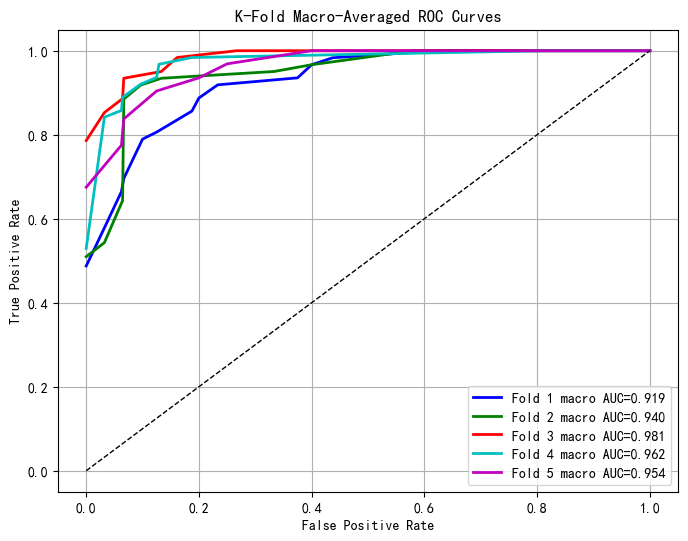


===== 推荐筛查阈值 =====
    target_sensitivity  threshold  Sensitivity  Specificity       PPV       NPV    FN    FP                                      selection_note
62                0.90       0.63     0.910256     0.862745  0.771739  0.949640   7.0  21.0  Sensitivity >= 0.90; maximize specificity and NPV.
80                0.85       0.81     0.858974     0.908497  0.827160  0.926667  11.0  14.0  Sensitivity >= 0.85; maximize specificity and NPV.
87                0.80       0.88     0.820513     0.934641  0.864865  0.910828  14.0  10.0  Sensitivity >= 0.80; maximize specificity and NPV.
筛查阈值表已保存: ./screening_curve_outputs\seed_42_kfold_oof_screening_threshold_table.xlsx
推荐阈值表已保存: ./screening_curve_outputs\seed_42_kfold_oof_recommended_screening_thresholds.xlsx


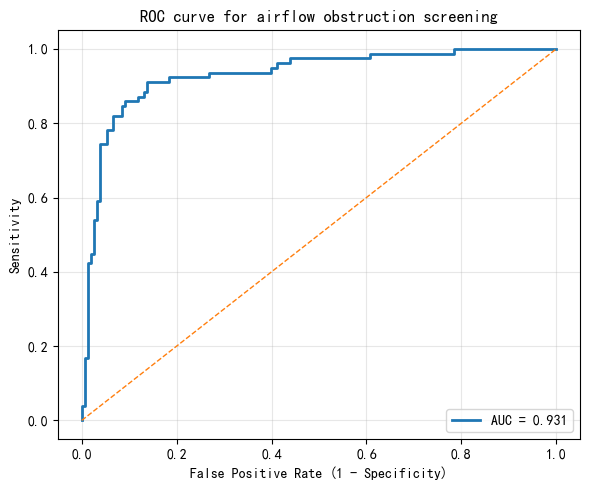


[PR bootstrap] 正在计算 PR 曲线 95%CI，n_bootstrap=1000 ...
[PR bootstrap] 有效bootstrap次数=1000; AP 95%CI=(0.769, 0.942); PR-AUC 95%CI=(0.761, 0.941)


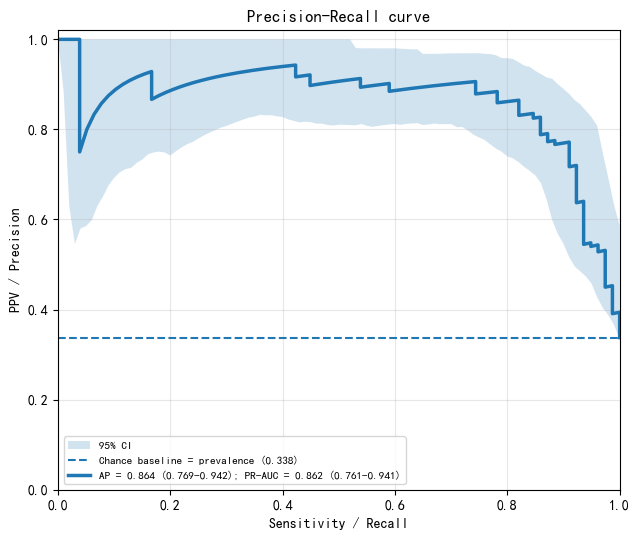

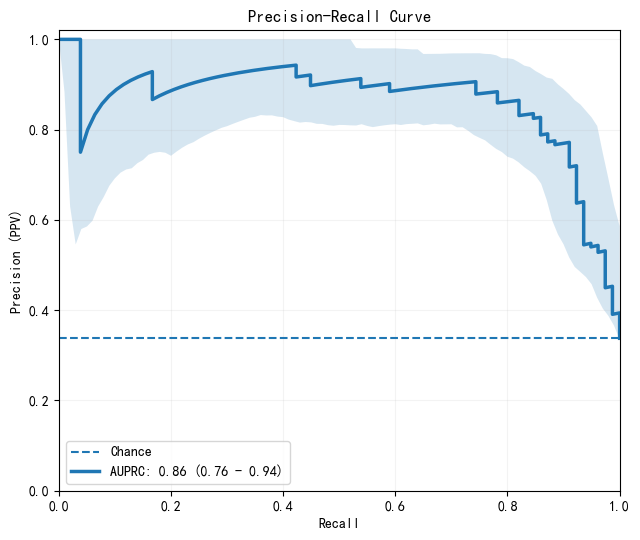

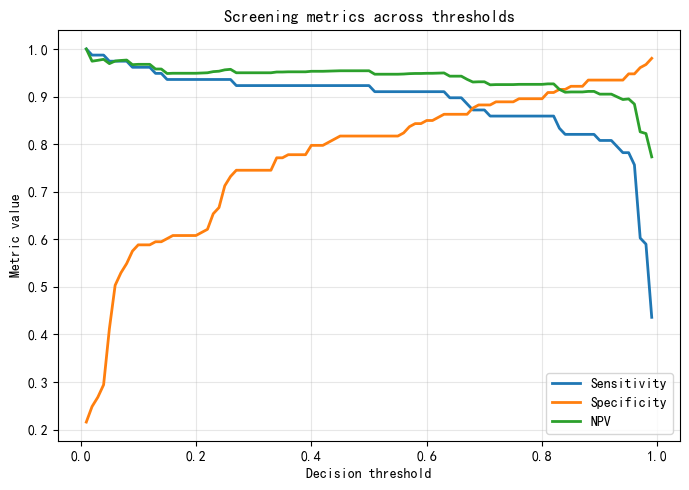

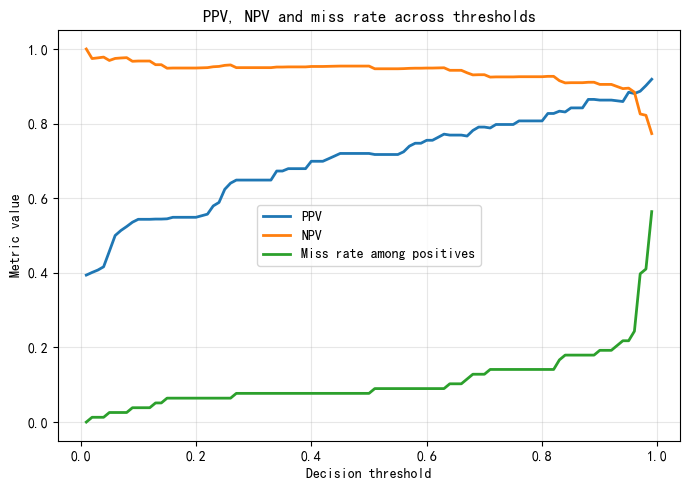

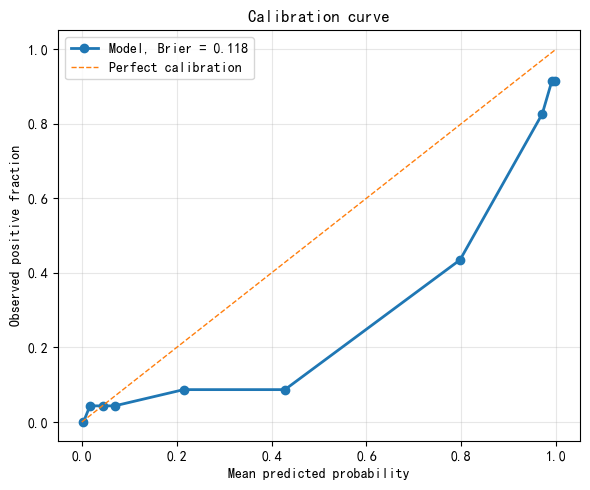

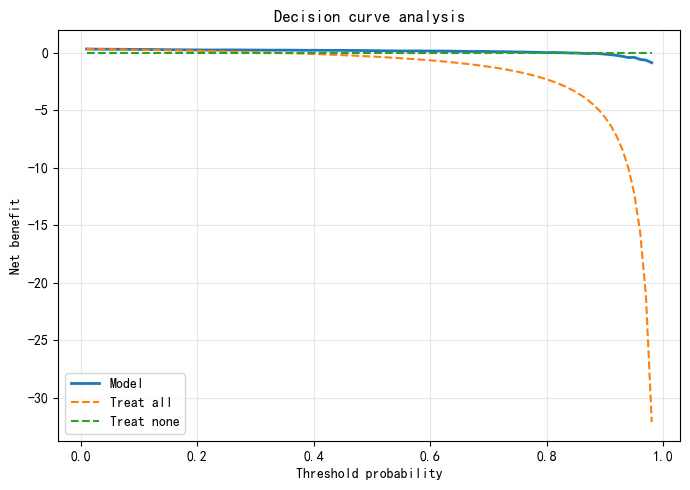

全部筛查曲线结果已保存: ./screening_curve_outputs\seed_42_kfold_oof_all_screening_outputs.xlsx
PR图已保存: ./screening_curve_outputs\seed_42_kfold_oof_precision_recall_curve.png
论文风格PR图已保存: ./screening_curve_outputs\seed_42_kfold_oof_precision_recall_curve_with_ci_chance.png
avg_shap_all_folds  (110,)

===== Overall Feature Importance (Mean SHAP) =====
              Feature  MeanSHAP
6   shortnessOfBreath  0.681455
1                 age  0.555860
14        tongueShape  0.475723
3      smokingHistory  0.441195
8        constitution  0.413684
17       coatingColor  0.386544
13        tongueColor  0.268691
16     coatingTexture  0.262356
7               cough  0.237254
10           lipColor  0.225768
2                 BMI  0.214327
9           faceColor  0.206293
12          faceGloss  0.144622
4                FHRD  0.129611
11          localFeat  0.049387
5     biofuelsHistory  0.048233
0              gender  0.021455
15    tongueCondition  0.009868


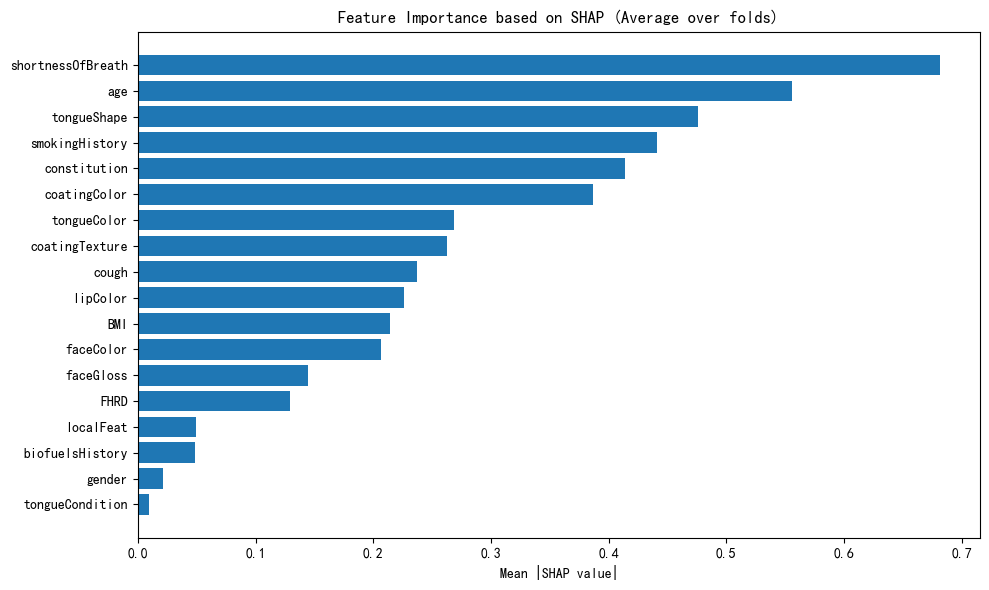


===== Overall Feature Importance (Class 0) =====
              Feature  MeanSHAP
6   shortnessOfBreath  0.669271
1                 age  0.545350
14        tongueShape  0.455796
3      smokingHistory  0.416153
8        constitution  0.394952
17       coatingColor  0.365697
16     coatingTexture  0.253207
13        tongueColor  0.237262
10           lipColor  0.234240
7               cough  0.219006
9           faceColor  0.208595
2                 BMI  0.206665
12          faceGloss  0.150886
4                FHRD  0.119358
11          localFeat  0.047134
5     biofuelsHistory  0.046418
0              gender  0.020789
15    tongueCondition  0.009446


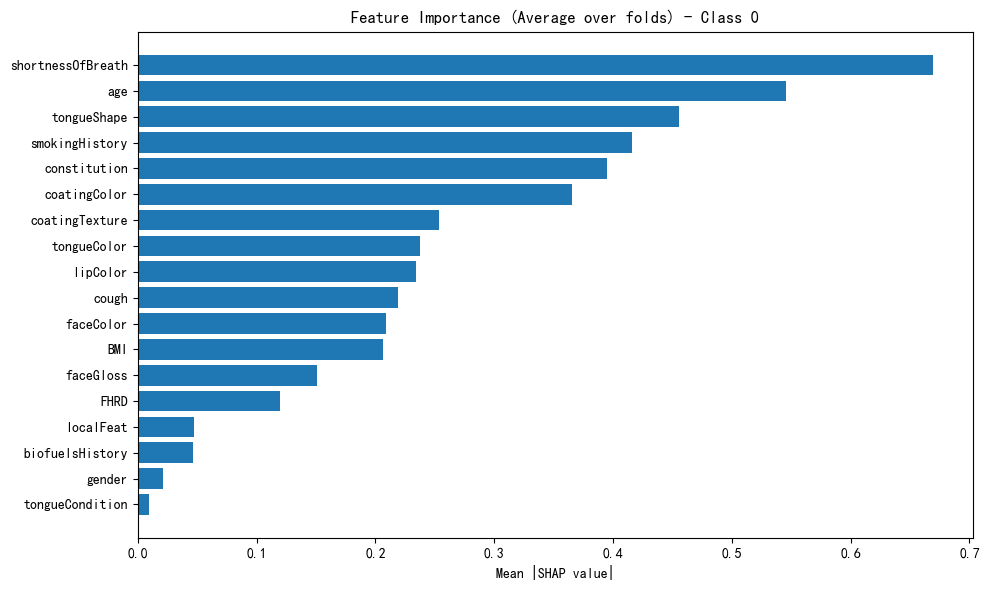


===== Overall Feature Importance (Class 1) =====
              Feature  MeanSHAP
6   shortnessOfBreath  0.693639
1                 age  0.566371
14        tongueShape  0.495650
3      smokingHistory  0.466237
8        constitution  0.432416
17       coatingColor  0.407392
13        tongueColor  0.300119
16     coatingTexture  0.271505
7               cough  0.255503
2                 BMI  0.221989
10           lipColor  0.217297
9           faceColor  0.203991
4                FHRD  0.139865
12          faceGloss  0.138358
11          localFeat  0.051641
5     biofuelsHistory  0.050048
0              gender  0.022122
15    tongueCondition  0.010290


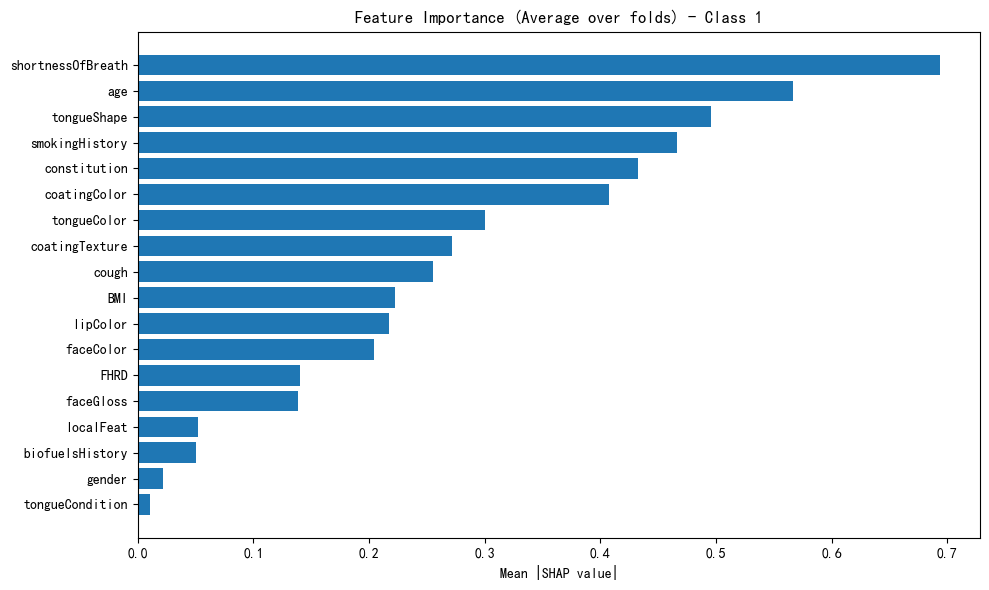

shap_values_all  (1629, 110, 2)
all_data  (1629, 110)

=== faceColor (slice=25:44) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


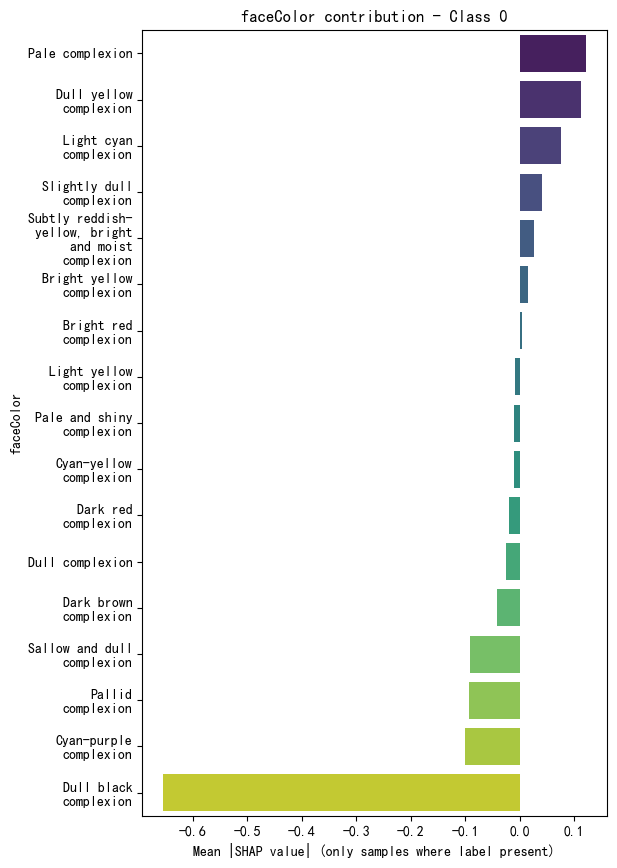

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


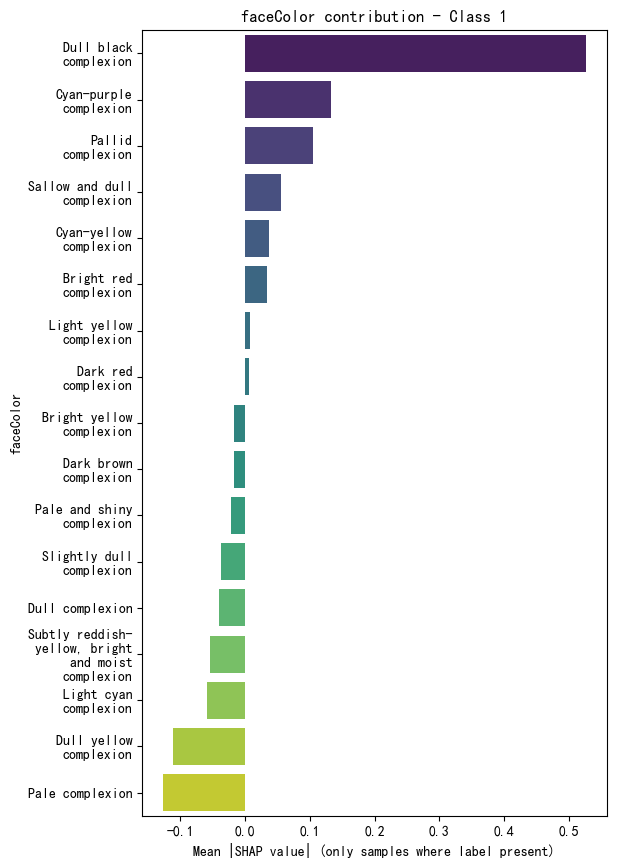

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== constitution (slice=8:25) ===


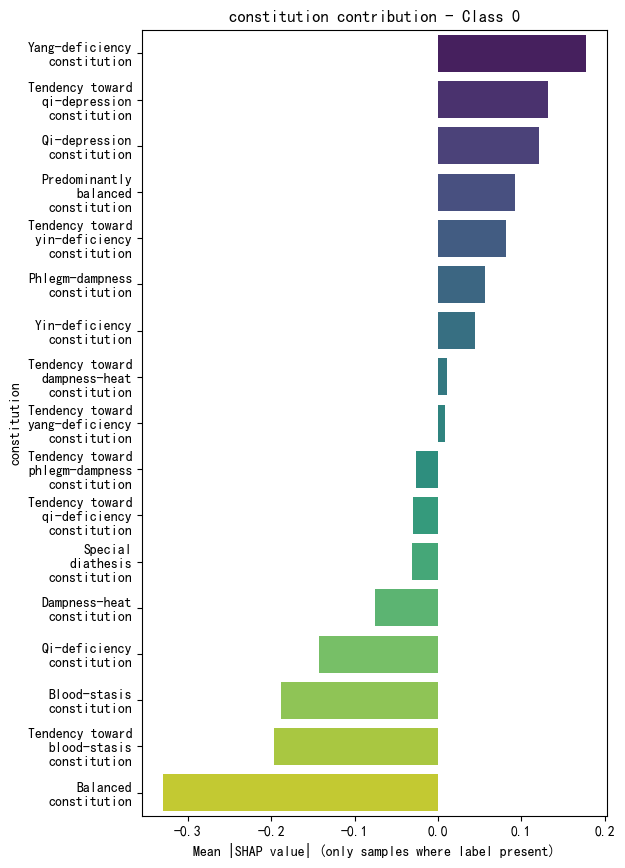

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


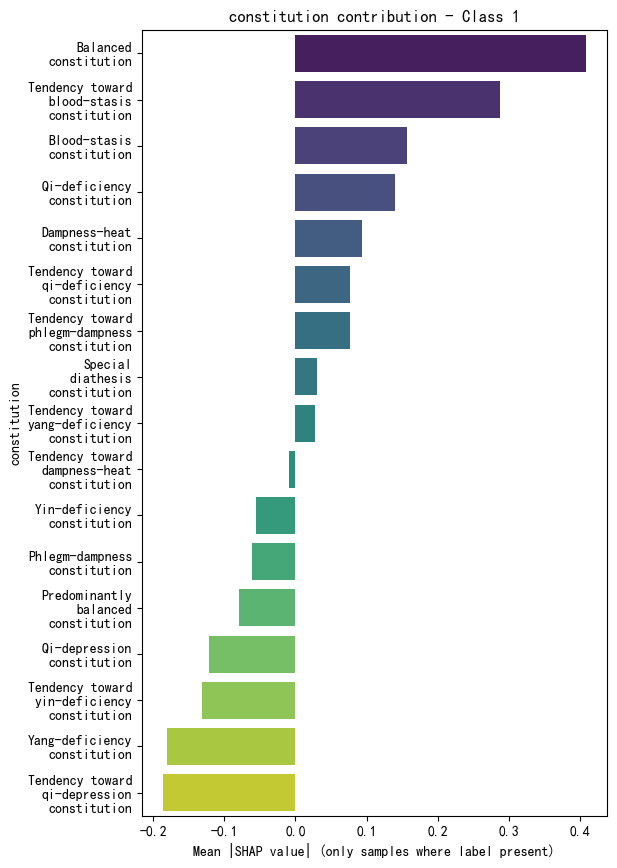

<Figure size 600x400 with 0 Axes>


=== tongueColor (slice=58:73) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


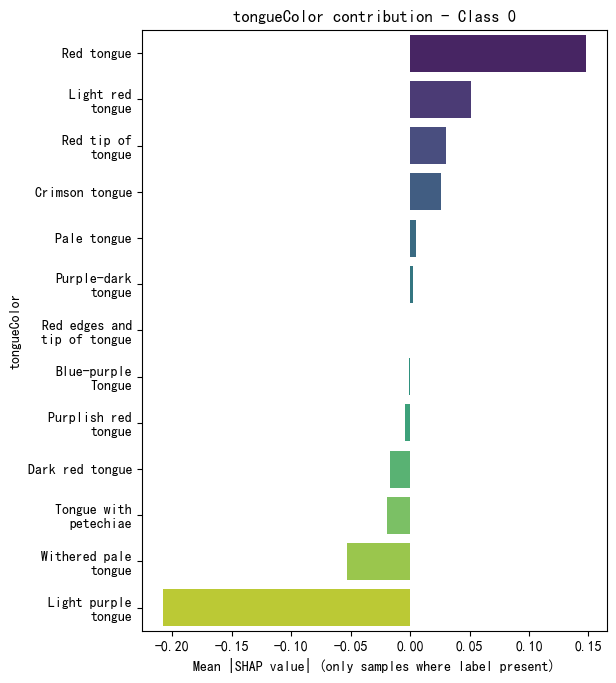

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


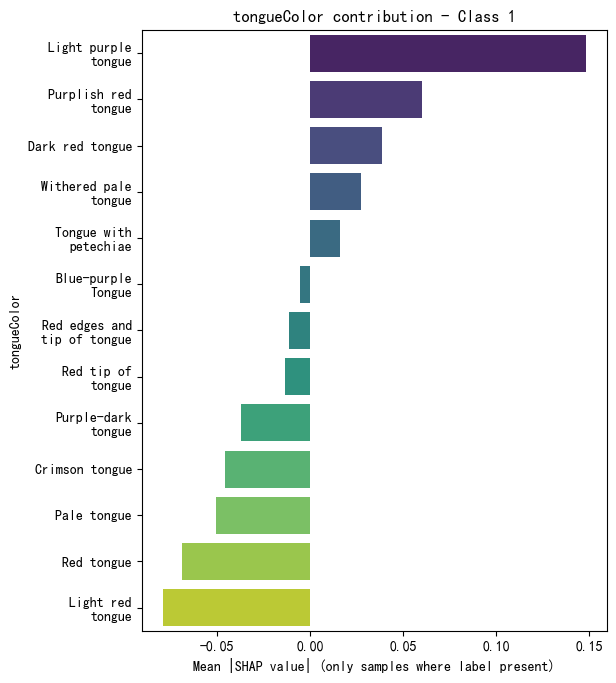

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== tongueShape (slice=73:82) ===


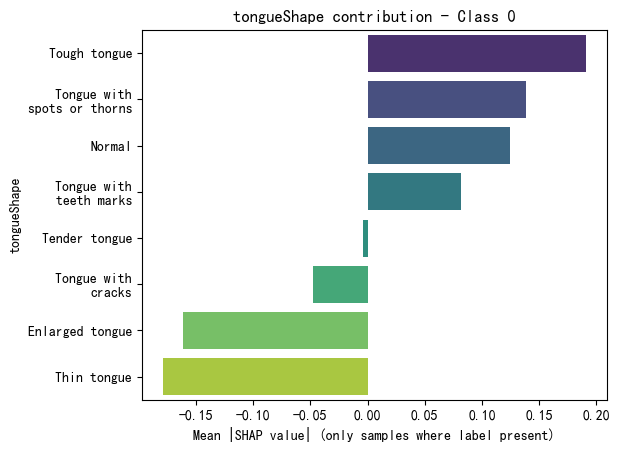

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


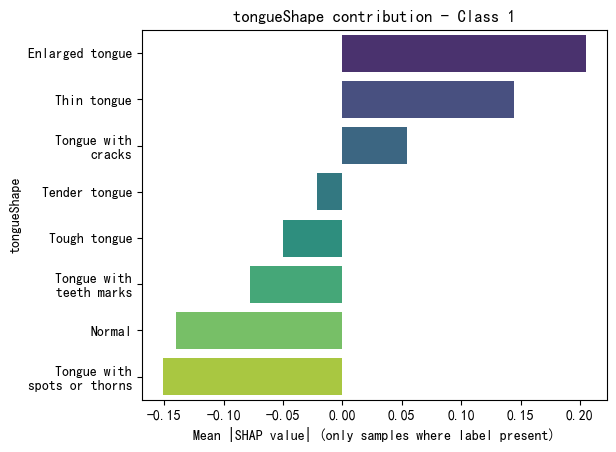

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



=== coatingTexture (slice=88:102) ===


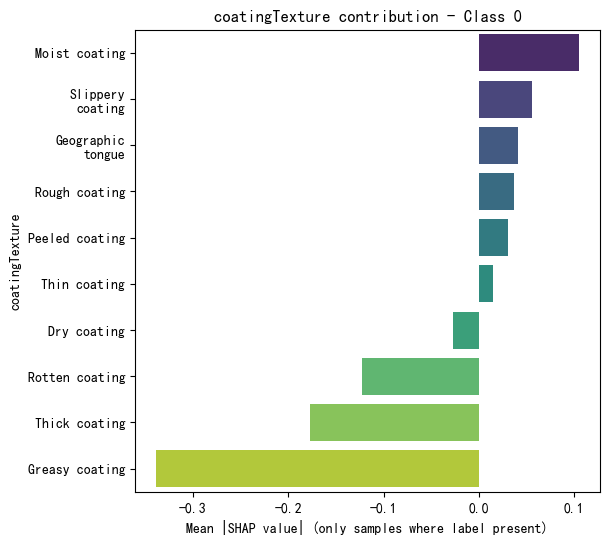

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


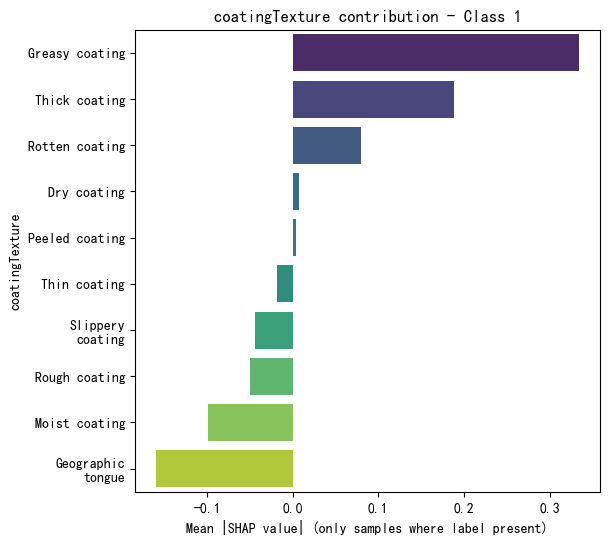

<Figure size 600x400 with 0 Axes>


=== coatingColor (slice=102:109) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


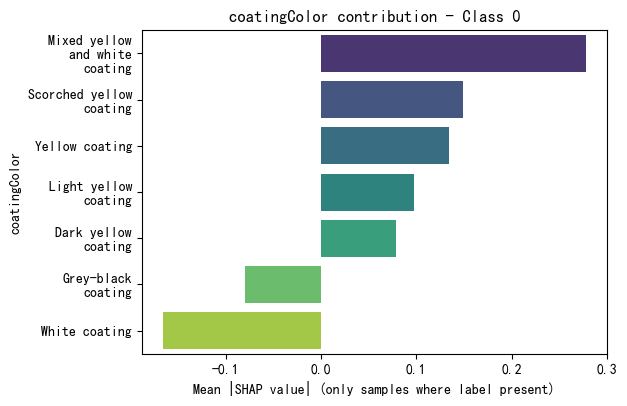

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


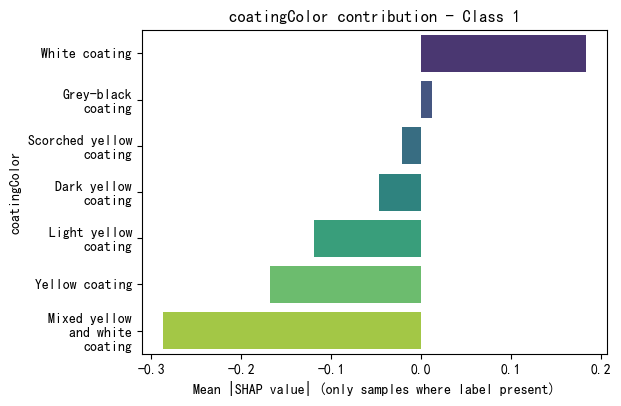

<Figure size 600x400 with 0 Axes>


=== lipColor (slice=44:52) ===


C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


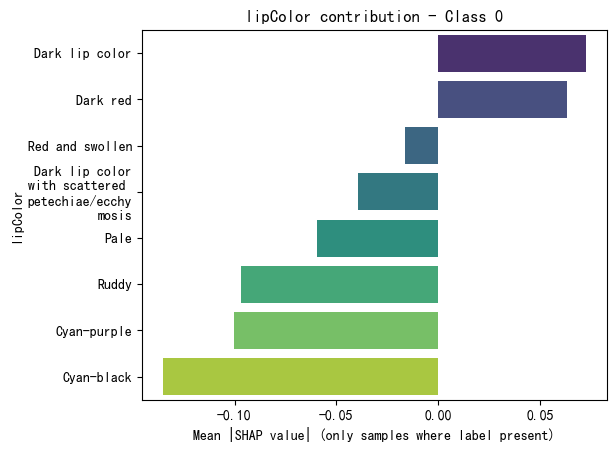

<Figure size 600x400 with 0 Axes>

C:\Users\25447\AppData\Local\Temp\ipykernel_43652\2758718298.py:1672: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


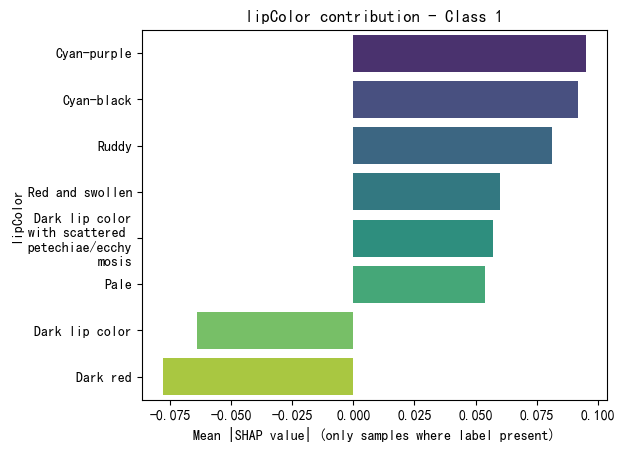

<Figure size 600x400 with 0 Axes>

In [19]:
import shap
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score, precision_recall_curve, average_precision_score, auc as sk_auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import calibration_curve

from itertools import cycle
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from copy import deepcopy
import os, random
import numpy as np
import textwrap

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

categorical_features = ["faceColor", "constitution", "tongueColor", "tongueShape", "coatingTexture", "coatingColor", "lipColor"]
feature_mappings = {
    "faceColor": 面色_mapping,
    "constitution": 体质_mapping,
    "tongueColor": 舌色_mapping,
    "tongueShape": 舌形_mapping,
    "coatingTexture": 苔质_mapping,  
    "coatingColor" : 苔色_mapping,
    "lipColor" : 唇色_mapping
}
feature_names = [
    "gender", "age",  "BMI", "smokingHistory", "FHRD", "biofuelsHistory", "shortnessOfBreath", 'cough', #"COPD-SQ Score",#
    "constitution", "faceColor", "lipColor", "localFeat", "faceGloss", "tongueColor", "tongueShape", 'tongueCondition', "coatingTexture", "coatingColor"
]

bins_dict = {'BMI':[0,18.5,24,28,100],
             'smokingHistory':[1,2,3,4]
            } 

plt.rcParams['font.sans-serif'] = ['SimHei']   # 或者 ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, kruskal

categorical_mappings = {
    'constitution': 体质_mapping,
    'faceColor': 面色_mapping,
    'lipColor': 唇色_mapping,
    'localFeat': 局部特征_mapping,
    'faceGloss': 面部光泽_mapping,
    'tongueColor': 舌色_mapping,
    'tongueShape': 舌形_mapping,
    'tongueCondition': 舌态_mapping,
    'coatingTexture': 苔质_mapping,
    'coatingColor': 苔色_mapping,
}

def generate_baseline_table_multilabel_with_significance(dataset,
                                                         categorical_features_mapping,
                                                         group_label='isCopd'):
    """
    Generate a baseline table (Table 1) with between-group significance tests

    Parameters:
    - dataset: list; each element is a sample containing a feature dictionary
    - categorical_features_mapping: dict; key = feature name, value = mapping dictionary (for decoding)
    - group_label: column name for the grouping label (default: isCopd)
    """

    all_data = []
    for i in range(len(dataset)):
        item = dataset[i]
        row = {}

        row['age'] = item['age'].item()
        row['BMI'] = item['BMI'].item()
        #row['COPD-SQ Score'] = item['copdSQ'].item()
        row['FHRD'] = item['FHRD'].item()
        
        row['smokingHistory'] = item['smokingHistory'].item()
        row['biofuelsHistory'] = item['biofuelsHistory'].item()
        row['shortnessOfBreath'] = item['shortnessOfBreath'].item()

        row['gender'] = item['gender'].item()
        for feat, mapping in categorical_features_mapping.items():
            row[feat] = multihot_to_bitmask(item[feat], mapping) #item[feat].item()


        #  isCopd ∈ {-1,0,1,2,3} →  ∈ {-1,0,1}
        raw_label = item[group_label].item()
        if raw_label < 0:
            new_label = -1      # No lung function/Unspecified
        elif raw_label == 0:
            new_label = 0       # normal
        else:
            new_label = 1       # 1, 2, and 3 are all classified as having "ventilatory dysfunction."
        row[group_label] = new_label
        
        all_data.append(row)

    df = pd.DataFrame(all_data)
    total = len(df)
    print("df.columns", df.columns)

    continuous_features = ['age', 'BMI']#, 'COPD-SQ Score']
    categorical_basic = ['gender', 'smokingHistory', 'FHRD', 'biofuelsHistory', 'shortnessOfBreath']

    summary = {}

    groups = sorted(df[group_label].unique())
    group_names = [f"{group_label}={g}" for g in groups]

    for feat in df.columns:
        if feat == group_label:
            continue

        if feat in continuous_features:
            # Continuous features: reported as mean ± standard deviation.
            descs = []
            values_by_group = []
            for g in groups:
                vals = df.loc[df[group_label]==g, feat].dropna()
                if len(vals) > 0:
                    descs.append(f"{vals.mean():.1f} ± {vals.std():.1f}")
                    values_by_group.append(vals)
                else:
                    descs.append("NA")

            # Multiple groups → ANOVA; two groups → t-test.
            if len(groups) > 2:
                stat, p = f_oneway(*values_by_group)
            else:
                p = stats.ttest_ind(values_by_group[0], values_by_group[1], equal_var=False)[1]

        elif feat in categorical_basic:
            # Generate a contingency table
            contingency = pd.crosstab(df[feat], df[group_label])
            # Chi-square test
            try:
                chi2, p, dof, ex = chi2_contingency(contingency)
            except:
                p = 1.0

            label_counts = {}
            for g in groups:
                sub = df[df[group_label] == g]
                total_g = len(sub)
                counts = sub[feat].value_counts()
                label_counts[g] = " | ".join([
                    f"{lbl} {cnt}({cnt/total_g*100:.1f}%)"
                    for lbl, cnt in counts.items()
                ])

        else:
            # Categorical Features
            mapping = categorical_features_mapping.get(feat, None)
            if mapping is None:
                continue

            # Decoding Bitwise Operations
            decoded_lists = df[feat].apply(lambda x: decode_labels(int(x), mapping))
            df_decoded = df.copy()
            df_decoded[feat] = decoded_lists

            # Calculate the frequency of each label
            label_counts = {}
            for g in groups:
                sub = df_decoded[df_decoded[group_label]==g]
                flat = [l for L in sub[feat] for l in L]
                total_g = len(sub)
                counts = pd.Series(flat).value_counts()
                label_counts[g] = " | ".join([
                    f"{lbl} {cnt}({cnt/total_g*100:.1f}%)"
                    for lbl, cnt in counts.items()
                ])

            # Constructing a Contingency Table
            contingency = []
            labels_union = sorted({l for L in df_decoded[feat] for l in L})
            for lbl in labels_union:
                row_ct = []
                for g in groups:
                    sub = df_decoded[df_decoded[group_label]==g]
                    flat = [l for L in sub[feat] for l in L]
                    row_ct.append(flat.count(lbl))
                contingency.append(row_ct)

            try:
                chi2, p, dof, ex = chi2_contingency(contingency)
            except:
                p = 1.0

        if p < 0.001:
            p_str = f"{p:.3e} ***"
        elif p < 0.01:
            p_str = f"{p:.3f} **"
        elif p < 0.05:
            p_str = f"{p:.3f} *"
        else:
            p_str = f"{p:.3f}"

        # ========= 汇总 =========
        if feat in continuous_features:
            row_summary = descs + [p_str]
        else:
            row_summary = [label_counts.get(g, 'NA') for g in groups] + [p_str]

        summary[feat] = row_summary

    # DataFrame
    columns = group_names + ['p值']
    summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=columns)
    summary_df = summary_df.reset_index().rename(columns={'index': '特征'})

    return summary_df

def generate_baseline_with_significance(dataset, feature_mappings=None):
    """
    Generate "Table 1" (including significance tests) based on the DataFrame `df` (which contains the `isCopd` label).
    feature_mappings: dict, optional; maps categorical feature labels to Chinese names.
    Returns: pandas.DataFrame; suitable for direct output or saving as a CSV file.
    """
    df = get_all_data_df(dataset)

    results = []
    # COPD vs non COPD 
    copd_group = df[df['isCopd'] > 0]
    noncopd_group = df[df['isCopd'] == 0]

    for feat in df.columns:
        if feat == 'isCopd':
            continue

        col_data = df[feat].dropna()

        if np.issubdtype(col_data.dtype, np.number) and col_data.nunique() > 5:
            # （Shapiro-Wilk）
            stat1, p1 = stats.shapiro(copd_group[feat]) if len(copd_group[feat])>=3 else (0,1)
            stat2, p2 = stats.shapiro(noncopd_group[feat]) if len(noncopd_group[feat])>=3 else (0,1)
            normal = (p1>0.05 and p2>0.05)
            if normal:
                stat, pval = stats.ttest_ind(copd_group[feat], noncopd_group[feat], equal_var=False)
            else:
                stat, pval = stats.mannwhitneyu(copd_group[feat], noncopd_group[feat])
            mean1, std1 = copd_group[feat].mean(), copd_group[feat].std()
            mean2, std2 = noncopd_group[feat].mean(), noncopd_group[feat].std()
            results.append({
                "Feature": feat,
                "COPD组": f"{mean1:.1f} ± {std1:.1f}",
                "非COPD组": f"{mean2:.1f} ± {std2:.1f}",
                "p值": format_pval(pval)
            })

        else:
            contingency = pd.crosstab(df[feat], df['isCopd'])
            if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                chi2, pval, _, _ = stats.chi2_contingency(contingency)
            else:
                pval = np.nan

            if feature_mappings and feat in feature_mappings:
                mapping = feature_mappings[feat]
                labels = [mapping.get(int(k), k) for k in contingency.index]
            else:
                labels = contingency.index
            results.append({
                "Feature": feat,
                "COPD组": summarize_category(contingency.iloc[:,1] if contingency.shape[1]>1 else contingency.iloc[:,0], labels),
                "非COPD组": summarize_category(contingency.iloc[:,0], labels),
                "p值": format_pval(pval)
            })

    table1 = pd.DataFrame(results)
    return table1


def summarize_category(series, labels):
    total = series.sum()
    parts = [f"{lbl} {cnt}({cnt/total*100:.1f}%)" for lbl, cnt in zip(labels, series)]
    return " | ".join(parts)


def format_pval(p):
    if pd.isna(p):
        return "-"
    if p < 0.001:
        return "<0.001 ***"
    elif p < 0.01:
        return f"{p:.3f} **"
    elif p < 0.05:
        return f"{p:.3f} *"
    else:
        return f"{p:.3f}"

def get_all_data_df(dataset):
    all_data = []
    for i in range(len(dataset)):
        item = dataset[i]
        row = {
            'age': item['age'].item(),
            'BMI': item['BMI'].item(),
            #'COPD-SQ Score': item.get('copdSQ', torch.tensor(0)).item() if isinstance(item.get('copdSQ', None), torch.Tensor) else (item['copdSQ'].item() if 'copdSQ' in item else np.nan),
            'gender': item['gender'].item(),
            'smokingHistory': item['smokingHistory'].item(),
            'FHRD': item['FHRD'].item(),
            'biofuelsHistory': item['biofuelsHistory'].item(),
            'shortnessOfBreath': item['shortnessOfBreath'].item(),

            'isCopd': item['isCopd'].item(),
        }

        # multi-hot → bitmask
        multilabel_fields = {
            'constitution': 体质_mapping,
            'faceColor': 面色_mapping,
            'lipColor': 唇色_mapping,
            'localFeat': 局部特征_mapping,
            'faceGloss': 面部光泽_mapping,
            'tongueColor': 舌色_mapping,
            'tongueShape': 舌形_mapping,
            'tongueCondition': 舌态_mapping,
            'coatingTexture': 苔质_mapping,
            'coatingColor': 苔色_mapping,
        }

        for feat, mapping in multilabel_fields.items():
            row[feat] = multihot_to_bitmask(item[feat], mapping)
        
        all_data.append(row)

    df = pd.DataFrame(all_data)
    return df

def multihot_to_bitmask(tensor, mapping):
    if not torch.is_tensor(tensor):
        # 已经是标量，直接返回
        return int(tensor)

    t = tensor.detach().cpu().view(-1)  # 展成一维
    if t.numel() == 1:
        # 还是标量
        return int(t.item())

    # 假设 multi-hot 中 >0.5 的位置表示“该标签存在”
    idxs = (t > 0.5).nonzero(as_tuple=False).view(-1).tolist()
    if len(idxs) == 0:
        return 0  # 没有任何标签，就当 0

    bitmask = 0
    for i in idxs:
        bitmask |= (1 << i)
    return int(bitmask)

def generate_baseline_text(dataset, bins_dict=None, save_txt=None):
    df = get_all_data_df(dataset)
    total = len(df)

    if bins_dict is None:
        bins_dict = {'BMI':[0,18.5,24,28,100], 'COPD-SQ Score':[0,16,100]}

    single_value_cats = {
        'gender': {1:'Male', 0:'Female'},
        'smokingHistory': {1:'从不抽烟', 2:'1~<15包*年', 3:'15~<30包*年', 4:'≥30包*年'},
        'FHRD': {1:'无', 2:'有'},
        'biofuelsHistory': {1:'无接触', 2:'有接触'},
        'shortnessOfBreath': {1:'没有气促', 2:'在平地急行或爬小坡时感觉气促', 3:'平地正常行走时感觉气促'},
        'isCopd': {0:'肺通气功能正常', 1:'轻度通气功能障碍', 2:'中度通气功能障碍', 3:'重度通气功能障碍'}  # 如果肺功能_mapping 是 label->index，注意下面会用 mapping.get(int(idx))
    }

    multilabel_fields = {
        'constitution': 体质_mapping,
        'faceColor': 面色_mapping,
        'lipColor': 唇色_mapping,
        'localFeat': 局部特征_mapping,
        'faceGloss': 面部光泽_mapping,
        'tongueColor': 舌色_mapping,
        'tongueShape': 舌形_mapping,
        'tongueCondition': 舌态_mapping,
        'coatingTexture': 苔质_mapping,
        'coatingColor': 苔色_mapping,
    }

    lines = []
    # Continuous features: mean ± std or by interval
    continuous_feats = ['age', 'BMI']#, 'COPD-SQ Score']
    for feat in continuous_feats:
        if feat in bins_dict:
            bins = bins_dict[feat]
            bin_labels = []
            for i in range(len(bins)-1):
                if i == 0:
                    lbl = f"<{bins[i+1]}"
                elif i == len(bins)-2:
                    lbl = f"{bins[i]} ≤ {feat} < {bins[i+1]}"
                else:
                    lbl = f"{bins[i]} ≤ {feat} < {bins[i+1]}"
                bin_labels.append(lbl)
            df['_bin'] = pd.cut(df[feat], bins=bins, labels=bin_labels, right=False)
            counts = df['_bin'].value_counts().reindex(bin_labels, fill_value=0)
            lines.append(f"{feat}")
            for lbl, cnt in counts.items():
                lines.append(f"{lbl}|{cnt}({cnt/total*100:.1f}%)")
            lines.append("")  
        else:
            mean, std = df[feat].mean(), df[feat].std()
            #lines.append(f"{feat}")
            lines.append(f"{feat} | {mean:.1f} ± {std:.1f}")
            lines.append("")

    # Print single-value classifications line by line.
    for feat, mapping in single_value_cats.items():
        lines.append(f"{feat}")
        counts = df[feat].value_counts().sort_index()
        for idx, cnt in counts.items():
            # mapping 可能是 {int:label} 或 {label:int}，我们先尝试用 get(int(idx))
            name = mapping.get(int(idx), mapping.get(str(idx), str(idx)))
            lines.append(f"{name}|{cnt}({cnt/total*100:.1f}%)")
        lines.append("")

    for feat, mapping in multilabel_fields.items():
        lines.append(f"{feat}")
        decoded_all = []
        for val in df[feat]:
            try:
                decoded = decode_labels(int(val), mapping)   # 你已有 decode_labels 实现
                decoded_all.extend(decoded)
            except Exception:
                pass
        if len(decoded_all) == 0:
            lines.append(f"Unknown\t{total}({100.0:.1f}%)")
            lines.append("")
            continue
        s = pd.Series(decoded_all)
        counts = s.value_counts()
        for lbl, cnt in counts.items():
            lines.append(f"{lbl}|{cnt}({cnt/total*100:.1f}%)")
        lines.append("")

    out_text = "\n".join(lines)

    if save_txt:
        with open(save_txt, "w", encoding="utf-8") as f:
            f.write(out_text)

    return out_text


def feature_value_shap_summary(shap_values, data, feature_names, feature_name, mapping):
    feat_idx = feature_names.index(feature_name)
    feat_vals = data[:, feat_idx]
    shap_feat = shap_values[:, feat_idx, :]  # shape: (n_samples, n_classes)

    summary = {}
    n_classes = shap_feat.shape[1]
    for class_idx in range(n_classes):
        df = pd.DataFrame({"encoded_value": feat_vals, "shap": shap_feat[:, class_idx]})
        # 解码特征值
        df["decoded_labels"] = df["encoded_value"].apply(lambda x: ", ".join(decode_labels(int(x), mapping)))
        grouped = df.groupby("decoded_labels")["shap"].mean().sort_values(ascending=False)
        summary[f"Class_{class_idx}"] = grouped
    return summary

def compute_classwise_shap_avg(shap_values):
    return np.mean(np.abs(shap_values), axis=0)  # shape: (n_features, n_classes)

class RuleGuidedWrapper(nn.Module):
    def __init__(self, base_model, feature_slices,  device):
        super().__init__()
        self.base_model = base_model
        self.feature_slices = feature_slices
        self.device = device

    def forward(self, x):
        x = x[:, :-1]              # [B, D]
        copd_sq = x[:, -1]
        logits, _ =  self.base_model(x, self.feature_slices, copd_sq, self.device)
        return logits


def loss_fn(criterion, logits, labels, sample_prior, lambda_prior=0.1, labeled_mask=None):
    if labeled_mask is None:
        labeled_mask = (labels >= 0)
    pred_loss = criterion(logits[labeled_mask], labels[labeled_mask]) if labeled_mask.any() else torch.tensor(0., device=logits.device)
    
    prior_loss = nn.KLDivLoss(reduction="batchmean")(
        F.log_softmax(logits[labeled_mask], dim=1), sample_prior[labeled_mask]
        #F.softmax(logits[labeled_mask], dim=1), sample_prior[labeled_mask]
    ) if labeled_mask.any() else torch.tensor(0., device=logits.device)
    
    total_loss = pred_loss + lambda_prior * prior_loss
    return total_loss, pred_loss, prior_loss

from torch.utils.data import WeightedRandomSampler, DataLoader

def make_weighted_sampler(y_train, positive_boost=3.0):
    y_train = np.asarray(y_train)

    sample_weights = np.ones(len(y_train), dtype=np.float64)

    valid_mask = y_train >= 0
    valid_y = y_train[valid_mask].astype(int)

    class_counts = np.bincount(valid_y, minlength=2)
    class_weights_np = 1.0 / (class_counts + 1e-8)

    class_weights_np[1] *= positive_boost

    for i, yy in enumerate(y_train):
        if yy >= 0:
            sample_weights[i] = class_weights_np[int(yy)]
        else:
            sample_weights[i] = np.mean(class_weights_np) * 0.3

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    return sampler





def compute_screening_threshold_table(y_true, y_score, thresholds=None):
    """
    计算不同阈值下的筛查指标。
    y_true: 0=正常，1=通气功能障碍/异常
    y_score: 模型预测阳性概率

    重点关注：Sensitivity、NPV、Specificity、PPV、漏诊数 FN。
    """
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)

    valid_mask = np.isfinite(y_score) & (y_true >= 0)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    if thresholds is None:
        thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)

    rows = []
    n = len(y_true)
    prevalence = float(np.mean(y_true == 1)) if n > 0 else np.nan

    for thr in thresholds:
        y_pred = (y_score >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        TN, FP, FN, TP = cm.ravel()

        sensitivity = TP / (TP + FN + 1e-8)
        specificity = TN / (TN + FP + 1e-8)
        ppv = TP / (TP + FP + 1e-8)
        npv = TN / (TN + FN + 1e-8)
        acc = (TP + TN) / (TP + TN + FP + FN + 1e-8)
        f1_pos = 2 * TP / (2 * TP + FP + FN + 1e-8)
        youden = sensitivity + specificity - 1
        pred_pos_rate = (TP + FP) / (TP + TN + FP + FN + 1e-8)
        miss_rate = FN / (TP + FN + 1e-8)

        rows.append({
            "threshold": float(thr),
            "n": int(n),
            "prevalence": prevalence,
            "TP": int(TP),
            "FP": int(FP),
            "FN": int(FN),
            "TN": int(TN),
            "Sensitivity": float(sensitivity),
            "Specificity": float(specificity),
            "PPV": float(ppv),
            "NPV": float(npv),
            "ACC": float(acc),
            "F1_positive": float(f1_pos),
            "Youden": float(youden),
            "Predicted_positive_rate": float(pred_pos_rate),
            "Miss_rate_among_positive": float(miss_rate),
        })

    return pd.DataFrame(rows)


def select_screening_thresholds(threshold_df, target_sensitivities=(0.90, 0.85, 0.80), min_specificity=0.30):
    """
    为筛查任务选择推荐阈值：
    在达到目标 sensitivity 的前提下，优先 specificity 更高，其次 NPV 更高。
    """
    rows = []
    for target_sen in target_sensitivities:
        cand = threshold_df[
            (threshold_df["Sensitivity"] >= target_sen) &
            (threshold_df["Specificity"] >= min_specificity)
        ].copy()

        if len(cand) == 0:
            cand = threshold_df[threshold_df["Sensitivity"] >= target_sen].copy()

        if len(cand) == 0:
            # 如果没有任何阈值达到目标敏感度，则选择 sensitivity 最高者
            best = threshold_df.sort_values(
                ["Sensitivity", "Specificity", "NPV"],
                ascending=False
            ).iloc[0].copy()
            note = f"No threshold reached target sensitivity {target_sen:.2f}; selected highest sensitivity."
        else:
            best = cand.sort_values(
                ["Specificity", "NPV", "PPV"],
                ascending=False
            ).iloc[0].copy()
            note = f"Sensitivity >= {target_sen:.2f}; maximize specificity and NPV."

        best["target_sensitivity"] = target_sen
        best["selection_note"] = note
        rows.append(best)

    return pd.DataFrame(rows)


def compute_decision_curve(y_true, y_score, thresholds=None):
    """
    Decision Curve Analysis (DCA)。
    net benefit = TP/N - FP/N * pt/(1-pt)
    """
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    valid_mask = np.isfinite(y_score) & (y_true >= 0)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    if thresholds is None:
        thresholds = np.round(np.arange(0.01, 0.99, 0.01), 2)

    n = len(y_true)
    prevalence = float(np.mean(y_true == 1)) if n > 0 else np.nan
    rows = []

    for pt in thresholds:
        y_pred = (y_score >= pt).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        TN, FP, FN, TP = cm.ravel()

        nb_model = (TP / n) - (FP / n) * (pt / (1 - pt))
        nb_all = prevalence - (1 - prevalence) * (pt / (1 - pt))
        nb_none = 0.0

        rows.append({
            "threshold": float(pt),
            "net_benefit_model": float(nb_model),
            "net_benefit_treat_all": float(nb_all),
            "net_benefit_treat_none": float(nb_none),
        })

    return pd.DataFrame(rows)



def _safe_pr_auc(y_true, y_score):
    """
    安全计算 AP 与 PR-AUC。
    注意：AP 是 sklearn 推荐的 average precision；PR-AUC 是对 PR 曲线做梯形积分。
    """
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)

    valid_mask = np.isfinite(y_score) & (y_true >= 0)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan, np.nan, None, None

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    pr_auc_val = sk_auc(recall, precision)
    return ap, pr_auc_val, precision, recall


def _interpolate_pr_curve_for_ci(y_true, y_score, recall_grid=None):
    """
    将 PR 曲线插值到统一 recall_grid 上，用于 bootstrap 置信区间。
    返回 precision_on_grid。
    """
    if recall_grid is None:
        recall_grid = np.linspace(0.0, 1.0, 101)

    precision, recall, _ = precision_recall_curve(y_true, y_score)

    # precision_recall_curve 返回的 recall 通常是从 1 到 0，需要排序后插值
    order = np.argsort(recall)
    recall_sorted = recall[order]
    precision_sorted = precision[order]

    # 去除重复 recall，保留同一 recall 下较高 precision，避免插值异常
    unique_recall = []
    unique_precision = []
    for r in np.unique(recall_sorted):
        p_vals = precision_sorted[recall_sorted == r]
        unique_recall.append(r)
        unique_precision.append(np.max(p_vals))

    unique_recall = np.asarray(unique_recall)
    unique_precision = np.asarray(unique_precision)

    # 保证覆盖 [0,1]
    precision_grid = np.interp(
        recall_grid,
        unique_recall,
        unique_precision,
        left=unique_precision[0],
        right=unique_precision[-1]
    )

    return precision_grid


def bootstrap_pr_curve_ci(
    y_true,
    y_score,
    n_bootstrap=1000,
    ci_alpha=0.95,
    random_state=42,
    recall_grid=None
):
    """
    Calculate 95% CIs for the PR curve, AP, and PR-AUC using bootstrapping.

    Outputs:
    - recall_grid: Unified recall x-axis
    - precision_mean/lower/upper: Mean precision and CI from bootstrapping
    - ap_ci: Bootstrap CI for AP
    - pr_auc_ci: Bootstrap CI for PR-AUC
    - bootstrap_df: Table of AP/PR-AUC values ​​from each bootstrap iteration
    """
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)

    valid_mask = np.isfinite(y_score) & (y_true >= 0)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    if recall_grid is None:
        recall_grid = np.linspace(0.0, 1.0, 101)

    rng = np.random.RandomState(random_state)
    n = len(y_true)

    precision_grid_list = []
    ap_list = []
    pr_auc_list = []

    for b in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        yt_b = y_true[idx]
        ys_b = y_score[idx]

        # bootstrap 样本中若只有一个类别，跳过
        if len(np.unique(yt_b)) < 2:
            continue

        ap_b, pr_auc_b, _, _ = _safe_pr_auc(yt_b, ys_b)
        if np.isfinite(ap_b) and np.isfinite(pr_auc_b):
            ap_list.append(ap_b)
            pr_auc_list.append(pr_auc_b)
            precision_grid_list.append(
                _interpolate_pr_curve_for_ci(yt_b, ys_b, recall_grid=recall_grid)
            )

    if len(ap_list) == 0:
        raise ValueError("Bootstrap 失败：所有 bootstrap 样本都只有单一类别。")

    precision_grid_arr = np.vstack(precision_grid_list)
    low_q = (1.0 - ci_alpha) / 2.0 * 100.0
    high_q = (1.0 + ci_alpha) / 2.0 * 100.0

    precision_mean = np.nanmean(precision_grid_arr, axis=0)
    precision_lower = np.nanpercentile(precision_grid_arr, low_q, axis=0)
    precision_upper = np.nanpercentile(precision_grid_arr, high_q, axis=0)

    ap_ci = (
        float(np.nanpercentile(ap_list, low_q)),
        float(np.nanpercentile(ap_list, high_q))
    )
    pr_auc_ci = (
        float(np.nanpercentile(pr_auc_list, low_q)),
        float(np.nanpercentile(pr_auc_list, high_q))
    )

    bootstrap_df = pd.DataFrame({
        "bootstrap_id": np.arange(len(ap_list)),
        "AP": ap_list,
        "PR_AUC": pr_auc_list,
    })

    pr_ci_df = pd.DataFrame({
        "recall_grid": recall_grid,
        "precision_mean_bootstrap": precision_mean,
        "precision_lower_ci": precision_lower,
        "precision_upper_ci": precision_upper,
    })

    return {
        "recall_grid": recall_grid,
        "precision_mean": precision_mean,
        "precision_lower": precision_lower,
        "precision_upper": precision_upper,
        "ap_ci": ap_ci,
        "pr_auc_ci": pr_auc_ci,
        "bootstrap_df": bootstrap_df,
        "pr_ci_df": pr_ci_df,
        "n_valid_bootstrap": len(ap_list),
    }


def plot_screening_curves_from_folds(
    fold_y_true,
    fold_y_score,
    output_dir="./screening_curve_outputs",
    prefix="kfold_oof",
    n_bootstrap=1000,
    ci_alpha=0.95,
    random_state=42,
    add_pr_ci=True,
    add_chance_baseline=True
):
    """
    Combine the out-of-fold test set predictions from all folds and plot the curves required for the screening task.

    Additions:
    1. Include a chance baseline in the PR curve, where the baseline equals the prevalence (proportion of positive cases).
    2. Add a shaded area representing the bootstrap 95% confidence interval (CI) to the PR curve.
    3. Save the table containing the bootstrap 95% CIs for AP/PR-AUC.

    Note: These curves utilize predictions from the test set of each fold, representing pooled out-of-fold performance.
    """
    os.makedirs(output_dir, exist_ok=True)

    y_true = np.concatenate([np.asarray(x).reshape(-1) for x in fold_y_true]).astype(int)
    y_score = np.concatenate([np.asarray(x).reshape(-1) for x in fold_y_score]).astype(float)

    valid_mask = np.isfinite(y_score) & (y_true >= 0)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        print("[Screening curves] 有效标签不足或只有一个类别，无法绘制筛查曲线。")
        return None

    prevalence = float(np.mean(y_true == 1))

    # 1) threshold table
    threshold_df = compute_screening_threshold_table(y_true, y_score)
    recommended_df = select_screening_thresholds(threshold_df)
    dca_df = compute_decision_curve(y_true, y_score)

    threshold_path = os.path.join(output_dir, f"{prefix}_screening_threshold_table.xlsx")
    recommended_path = os.path.join(output_dir, f"{prefix}_recommended_screening_thresholds.xlsx")
    dca_path = os.path.join(output_dir, f"{prefix}_decision_curve_table.xlsx")
    threshold_df.to_excel(threshold_path, index=False)
    recommended_df.to_excel(recommended_path, index=False)
    dca_df.to_excel(dca_path, index=False)

    print("\n===== 推荐筛查阈值 =====")
    print(recommended_df[[
        "target_sensitivity", "threshold", "Sensitivity", "Specificity", "PPV", "NPV", "FN", "FP", "selection_note"
    ]])
    print(f"筛查阈值表已保存: {threshold_path}")
    print(f"推荐阈值表已保存: {recommended_path}")

    # 2) ROC curve
    fpr, tpr, roc_thr = roc_curve(y_true, y_score)
    roc_auc_val = roc_auc_score(y_true, y_score)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("Sensitivity")
    plt.title("ROC curve for airflow obstruction screening")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    roc_path = os.path.join(output_dir, f"{prefix}_roc_curve.png")
    plt.savefig(roc_path, dpi=300)
    plt.show()

    # 3) PR curve with 95% CI and chance baseline
    precision, recall, pr_thr = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    pr_auc_val = sk_auc(recall, precision)

    pr_boot = None
    if add_pr_ci:
        print(f"\n[PR bootstrap] 正在计算 PR 曲线 {int(ci_alpha * 100)}%CI，n_bootstrap={n_bootstrap} ...")
        pr_boot = bootstrap_pr_curve_ci(
            y_true=y_true,
            y_score=y_score,
            n_bootstrap=n_bootstrap,
            ci_alpha=ci_alpha,
            random_state=random_state,
            recall_grid=np.linspace(0.0, 1.0, 101)
        )
        print(
            f"[PR bootstrap] 有效bootstrap次数={pr_boot['n_valid_bootstrap']}; "
            f"AP {int(ci_alpha*100)}%CI=({pr_boot['ap_ci'][0]:.3f}, {pr_boot['ap_ci'][1]:.3f}); "
            f"PR-AUC {int(ci_alpha*100)}%CI=({pr_boot['pr_auc_ci'][0]:.3f}, {pr_boot['pr_auc_ci'][1]:.3f})"
        )

        pr_boot["bootstrap_df"].to_excel(
            os.path.join(output_dir, f"{prefix}_pr_bootstrap_metrics.xlsx"),
            index=False
        )
        pr_boot["pr_ci_df"].to_excel(
            os.path.join(output_dir, f"{prefix}_pr_curve_ci_table.xlsx"),
            index=False
        )

    plt.figure(figsize=(6.5, 5.5))

    if pr_boot is not None:
        plt.fill_between(
            pr_boot["recall_grid"],
            pr_boot["precision_lower"],
            pr_boot["precision_upper"],
            alpha=0.20,
            label=f"{int(ci_alpha * 100)}% CI"
        )

    if add_chance_baseline:
        plt.axhline(
            prevalence,
            linestyle="--",
            lw=1.5,
            label=f"Chance baseline = prevalence ({prevalence:.3f})"
        )

    if pr_boot is not None:
        label_text = (
            f"AP = {ap:.3f} ({pr_boot['ap_ci'][0]:.3f}-{pr_boot['ap_ci'][1]:.3f}); "
            f"PR-AUC = {pr_auc_val:.3f} ({pr_boot['pr_auc_ci'][0]:.3f}-{pr_boot['pr_auc_ci'][1]:.3f})"
        )
    else:
        label_text = f"AP = {ap:.3f}, PR-AUC = {pr_auc_val:.3f}"

    plt.plot(recall, precision, lw=2.5, label=label_text)
    plt.xlabel("Sensitivity / Recall")
    plt.ylabel("PPV / Precision")
    plt.title("Precision-Recall curve")
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.legend(loc="best", fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    pr_path = os.path.join(output_dir, f"{prefix}_precision_recall_curve.png")
    plt.savefig(pr_path, dpi=300)
    plt.show()

    # 同时保存一张更接近论文排版风格的 PR 图
    plt.figure(figsize=(6.5, 5.5))
    if pr_boot is not None:
        plt.fill_between(
            pr_boot["recall_grid"],
            pr_boot["precision_lower"],
            pr_boot["precision_upper"],
            alpha=0.18
        )
    if add_chance_baseline:
        plt.axhline(
            prevalence,
            linestyle="--",
            lw=1.5,
            label="Chance"
        )
    plt.plot(
        recall,
        precision,
        lw=2.5,
        label=f"AUPRC: {pr_auc_val:.2f} ({pr_boot['pr_auc_ci'][0]:.2f} - {pr_boot['pr_auc_ci'][1]:.2f})" if pr_boot is not None else f"AUPRC: {pr_auc_val:.2f}"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision-Recall Curve")
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.legend(loc="best")
    plt.grid(alpha=0.15)
    plt.tight_layout()
    pr_paper_path = os.path.join(output_dir, f"{prefix}_precision_recall_curve_with_ci_chance.png")
    plt.savefig(pr_paper_path, dpi=300)
    plt.show()

    # 4) Threshold-Sensitivity-Specificity curve
    plt.figure(figsize=(7, 5))
    plt.plot(threshold_df["threshold"], threshold_df["Sensitivity"], lw=2, label="Sensitivity")
    plt.plot(threshold_df["threshold"], threshold_df["Specificity"], lw=2, label="Specificity")
    plt.plot(threshold_df["threshold"], threshold_df["NPV"], lw=2, label="NPV")
    plt.xlabel("Decision threshold")
    plt.ylabel("Metric value")
    plt.title("Screening metrics across thresholds")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    sens_spec_path = os.path.join(output_dir, f"{prefix}_threshold_sensitivity_specificity_npv.png")
    plt.savefig(sens_spec_path, dpi=300)
    plt.show()

    # 5) Threshold-PPV-NPV curve
    plt.figure(figsize=(7, 5))
    plt.plot(threshold_df["threshold"], threshold_df["PPV"], lw=2, label="PPV")
    plt.plot(threshold_df["threshold"], threshold_df["NPV"], lw=2, label="NPV")
    plt.plot(threshold_df["threshold"], threshold_df["Miss_rate_among_positive"], lw=2, label="Miss rate among positives")
    plt.xlabel("Decision threshold")
    plt.ylabel("Metric value")
    plt.title("PPV, NPV and miss rate across thresholds")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    ppv_npv_path = os.path.join(output_dir, f"{prefix}_threshold_ppv_npv_miss_rate.png")
    plt.savefig(ppv_npv_path, dpi=300)
    plt.show()

    # 6) Calibration curve
    frac_pos, mean_pred = calibration_curve(y_true, y_score, n_bins=10, strategy="quantile")
    brier = np.mean((y_score - y_true) ** 2)
    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, marker="o", lw=2, label=f"Model, Brier = {brier:.3f}")
    plt.plot([0, 1], [0, 1], "--", lw=1, label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive fraction")
    plt.title("Calibration curve")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    calibration_path = os.path.join(output_dir, f"{prefix}_calibration_curve.png")
    plt.savefig(calibration_path, dpi=300)
    plt.show()

    # 7) Decision Curve Analysis
    plt.figure(figsize=(7, 5))
    plt.plot(dca_df["threshold"], dca_df["net_benefit_model"], lw=2, label="Model")
    plt.plot(dca_df["threshold"], dca_df["net_benefit_treat_all"], "--", lw=1.5, label="Treat all")
    plt.plot(dca_df["threshold"], dca_df["net_benefit_treat_none"], "--", lw=1.5, label="Treat none")
    plt.xlabel("Threshold probability")
    plt.ylabel("Net benefit")
    plt.title("Decision curve analysis")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    dca_fig_path = os.path.join(output_dir, f"{prefix}_decision_curve_analysis.png")
    plt.savefig(dca_fig_path, dpi=300)
    plt.show()

    # 8) 保存总表
    summary_path = os.path.join(output_dir, f"{prefix}_all_screening_outputs.xlsx")
    with pd.ExcelWriter(summary_path) as writer:
        threshold_df.to_excel(writer, sheet_name="threshold_metrics", index=False)
        recommended_df.to_excel(writer, sheet_name="recommended_thresholds", index=False)
        dca_df.to_excel(writer, sheet_name="decision_curve", index=False)
        pr_summary_df = pd.DataFrame([{
            "prevalence_chance_baseline": prevalence,
            "AP": ap,
            "AP_CI_lower": pr_boot["ap_ci"][0] if pr_boot is not None else np.nan,
            "AP_CI_upper": pr_boot["ap_ci"][1] if pr_boot is not None else np.nan,
            "PR_AUC": pr_auc_val,
            "PR_AUC_CI_lower": pr_boot["pr_auc_ci"][0] if pr_boot is not None else np.nan,
            "PR_AUC_CI_upper": pr_boot["pr_auc_ci"][1] if pr_boot is not None else np.nan,
            "n_bootstrap_valid": pr_boot["n_valid_bootstrap"] if pr_boot is not None else np.nan,
        }])
        pr_summary_df.to_excel(writer, sheet_name="pr_curve_summary", index=False)
        if pr_boot is not None:
            pr_boot["pr_ci_df"].to_excel(writer, sheet_name="pr_curve_CI", index=False)
            pr_boot["bootstrap_df"].to_excel(writer, sheet_name="pr_bootstrap_metrics", index=False)

    print(f"全部筛查曲线结果已保存: {summary_path}")
    print(f"PR图已保存: {pr_path}")
    print(f"论文风格PR图已保存: {pr_paper_path}")

    return {
        "y_true": y_true,
        "y_score": y_score,
        "threshold_df": threshold_df,
        "recommended_df": recommended_df,
        "dca_df": dca_df,
        "roc_auc": roc_auc_val,
        "average_precision": ap,
        "average_precision_ci": pr_boot["ap_ci"] if pr_boot is not None else None,
        "pr_auc": pr_auc_val,
        "pr_auc_ci": pr_boot["pr_auc_ci"] if pr_boot is not None else None,
        "prevalence_chance_baseline": prevalence,
        "brier_score": brier,
        "pr_bootstrap": pr_boot,
    }

def train_eval_kfold_LTN_Rule(model_class, dataset, feature_names, modal_slices, feature_slices, n_splits=5,
                              n_epochs=100, lr=0.0005, lambda_logic=2.0, lambda_prior=0.1,
                              batch_size=32, device="cuda", seed=42, val_ratio=0.15, n_heads=4, n_layers=1,
                              best_model_path=r'D:\code\copd\copd_best_overall.bin'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    set_seed(seed)

    baseline_table = generate_baseline_text(dataset)
    print("===== Table 1. Baseline characteristics of participants =====")
    print(baseline_table)   

    summary_df = generate_baseline_table_multilabel_with_significance(
        dataset=dataset,
        categorical_features_mapping=categorical_mappings,
        group_label='isCopd'  # 
    )
    pd.set_option('display.max_columns', None)      
    pd.set_option('display.max_rows', None)         
    pd.set_option('display.width', 2000)            
    pd.set_option('display.max_colwidth', None)     
    #pd.set_option('display.expand_frame_repr', False)  
    print(summary_df)
    summary_df.to_excel("baseline_table.xlsx", index=False)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_auc = []
    all_acc = []
    all_f1 = []
    all_sens = []
    all_spec = []
    all_shap_values = []
    all_data_list = []
    all_shap_explanations = []
    fold_shap_avg = []

    fold_fpr = []
    fold_tpr = []

    fold_y_true_for_screening = []
    fold_y_score_for_screening = []

    global_best_score = -np.inf
    global_best_fold = None
    global_best_checkpoint = None

    X_tests, y_tests = [], []

    X = []
    y = []
    copd_sq_list = []
    for i in range(len(dataset)):
        sample = dataset[i]
        label = sample["isCopd"].item()
        sample.pop("isCopd")
        copd_sq_val = float(sample.pop("copdSQ")) if "copdSQ" in sample else np.nan
        feat_list = list(sample.values())
        x = torch.cat(feat_list, dim=0).numpy()
        X.append(x)
  
        # ===== 4-Class Classification → Binary Classification =====
        if label < 0:
            # -1 is still used to represent "unlabeled samples."
            bin_label = -1
        else:
            # 0 = Normal; all other values ​​{1, 2, 3} are recorded as 1 (indicating ventilatory dysfunction).
            bin_label = 0 if label == 0 else 1
        
        y.append(bin_label)
        copd_sq_list.append(copd_sq_val)
    X = np.array(X)
    y = np.array(y)
    copd_sq_array = np.array(copd_sq_list, dtype=float)
    print("X.shape", X[1])
    print(" y.shape",  y.shape)

    n_classes = 2   
    value_shap_per_class = {c: {feat: {} for feat in categorical_features} 
                            for c in range(n_classes)}


    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        print(f"\n===== Fold {fold+1}/{n_splits} =====")
        X_test, y_test = X[test_idx], y[test_idx]
        copd_test = copd_sq_array[test_idx]
    
        y_train_all = y[train_idx]
    
        labeled_rel = np.where(y_train_all != -1)[0]     
        unlabeled_rel = np.where(y_train_all == -1)[0]   
    
        # val 
        val_ratio = 0.15
    
        if len(labeled_rel) >= 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed + fold)
            tr_rel_lab, val_rel_lab = next(sss.split(np.zeros(len(labeled_rel)), y_train_all[labeled_rel]))
    
            train2_rel_lab = labeled_rel[tr_rel_lab]   
            val_rel = labeled_rel[val_rel_lab]         
        else:
            train2_rel_lab = labeled_rel
            val_rel = np.array([], dtype=int)
    
        # Training set = Labeled training portion + (optional) unlabeled samples (maintain your usage of logic_rules)
        train2_rel_all = np.concatenate([train2_rel_lab, unlabeled_rel]) if len(unlabeled_rel) > 0 else train2_rel_lab
    
        train2_idx = train_idx[train2_rel_all]
        val_idx = train_idx[val_rel]
    
        X_train, y_train = X[train2_idx], y[train2_idx]
        copd_train = copd_sq_array[train2_idx]
    
        X_val, y_val = X[val_idx], y[val_idx]
        copd_val = copd_sq_array[val_idx]
    
      
        X_tests.append(X_test)
        y_tests.append(y_test)
        #copd_train, copd_test = copd_sq_array[train_idx], copd_sq_array[test_idx]
       
        model = model_class(
            input_dim=X.shape[1],
            hidden_dim=32,
            output_dim=2,
            modal_slices=modal_slices,
            rule_feat_dim=9,
            n_heads=n_heads,
            n_layers=n_layers
        ).to(device)
        #criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        from sklearn.utils.class_weight import compute_class_weight
        valid_train_y = y_train[y_train >= 0].astype(int)
        
        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.array([0, 1]),
            y=valid_train_y
        )
        
        class_weights = torch.tensor(
            class_weights,
            dtype=torch.float32,
            device=device
        )
        
        # Increase the weight of the positive class.
        positive_weight_boost = 10
        class_weights[1] = class_weights[1] * positive_weight_boost
        
        print("class_weights:", class_weights)        
        criterion = nn.CrossEntropyLoss(weight=class_weights)
   

        # ---- DataLoader ----
        train_dataset = torch.utils.data.TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long),
            torch.tensor(copd_train, dtype=torch.float32)
        )
        val_dataset = torch.utils.data.TensorDataset(
                torch.tensor(X_val, dtype=torch.float32),
                torch.tensor(y_val, dtype=torch.long),
                torch.tensor(copd_val, dtype=torch.float32)
        )
        test_dataset = torch.utils.data.TensorDataset(
            torch.tensor(X_test, dtype=torch.float32),
            torch.tensor(y_test, dtype=torch.long),
            torch.tensor(copd_test, dtype=torch.float32)
        )
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        #train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, shuffle=False)
        val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        alpha = 0.7
        patience = 320               
        best_score = -np.inf
        best_state = None
        patience_counter = 0

        # ---- Training ----
        for epoch in range(n_epochs):
            model.train()
            total_pred_loss, total_logic_loss = 0, 0
            for Xb, yb, copd_b in train_loader:
                Xb, yb, copd_b = Xb.to(device), yb.to(device), copd_b.to(device)

                logits, sample_prior  = model(Xb, feature_slices, copd_b, device)
                probs = F.softmax(logits, dim=1)

                # labeled mask
                labeled_mask = (yb >= 0)

                #---- 1. 预测损失 + 先验约束损失 ----
                pred_total_loss , pred_loss, prior_loss  = loss_fn(criterion, 
                    logits, yb, sample_prior, lambda_prior=lambda_prior, labeled_mask=labeled_mask
                )

                # logic loss on all (unlabeled mask optional)               
                
                logic_loss = torch.tensor(0., device=device)
                unlabeled_mask = ~labeled_mask
                if unlabeled_mask.any():
                    X_unlab = Xb[unlabeled_mask]
                    probs_unlab = probs[unlabeled_mask]
                    copd_sq_unlab = copd_b[unlabeled_mask]
                    logic_loss = logic_rules(probs_unlab, X_unlab, feature_slices, copd_sq_unlab, device)
                else:
                    logic_loss = 0 * logits.sum() #torch.tensor(0., device=device)

 
                loss = pred_total_loss + lambda_logic * logic_loss
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_pred_loss += pred_total_loss.item()
                total_logic_loss += logic_loss.item()

            if (epoch+1) % 20 == 0:
                print(f"Epoch [{epoch+1}/{n_epochs}] | loss={loss:.4f} | pred_loss={pred_total_loss:.4f} | logic_loss={logic_loss:.4f}")

            # ========= Perform validation after each epoch=========
            model.eval()
            all_probs = []
            all_labels = []

            with torch.no_grad():
                for xb, yb, cb in val_loader:      
                    xb, yb, cb = xb.to(device), yb.to(device), cb.to(device)
                    logits, _ = model(xb, feature_slices, cb, device)
                    probs = F.softmax(logits, dim=1).cpu().numpy()
                    all_probs.append(probs)
                    all_labels.append(yb.cpu().numpy())
        
            all_probs = np.vstack(all_probs)
            all_labels = np.concatenate(all_labels)

            valid_mask = all_labels != -1
            all_probs = all_probs[valid_mask]
            all_labels = all_labels[valid_mask]

            if len(all_labels) > 0 :
                y_pred = np.argmax(all_probs, axis=1)
                val_acc = accuracy_score(all_labels, y_pred)           
                val_auc = roc_auc_score(all_labels, all_probs[:, 1])

                cm = confusion_matrix(all_labels, y_pred, labels=[0, 1])
                TN, FP, FN, TP = cm.ravel()
                
                val_sensitivity = TP / (TP + FN + 1e-8)
                val_specificity = TN / (TN + FP + 1e-8)
                
                #val_score = alpha * val_auc + (1 - alpha) * val_acc
                val_score = 0.4 * val_auc + 0.3 * val_acc + 0.3 * val_sensitivity
            else:
                val_auc = 0.0  # 
                val_score = 0.0

            if (epoch+1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{n_epochs}] "
                      f"loss={loss:.4f} pred_loss={pred_total_loss:.4f} logic_loss={logic_loss:.4f} "
                      f"val_auc={val_auc:.3f}  val_acc={val_acc:.3f}  val_score score={val_score:.3f}  best score={best_score:.3f}")
        
            # ========= Early stopping logic =========
            if val_score  > best_score + 1e-4:  
                best_score = val_score
                best_state = deepcopy(model.state_dict())
                patience_counter = 0 
            else:
                patience_counter += 1
                #print(f"  No improvement, patience {patience_counter}/{patience}")
        
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}, val_auc={val_auc:.3f}  val_acc={val_acc:.3f},  best val score={best_score:.3f}")
                break

        if best_state is not None:
            model.load_state_dict(best_state)
        print("Start validation ")

        fold_model_path = best_model_path.replace(".bin", f"_fold{fold+1}.bin")
        fold_checkpoint = {
            "state_dict": deepcopy(model.state_dict()),
            "input_dim": int(X.shape[1]),
            "hidden_dim": 32,
            "output_dim": 2,
            "modal_slices": modal_slices,
            "feature_slices": feature_slices,
            "rule_feat_dim": 9,
            "n_heads": n_heads,
            "n_layers": n_layers,
            "fold": fold + 1,
            "best_score": float(best_score),
            "seed": seed,
        }
        torch.save(fold_checkpoint, fold_model_path)
        print(f"Saved fold-best model to: {fold_model_path}")

        if best_score > global_best_score:
            global_best_score = float(best_score)
            global_best_fold = fold + 1
            global_best_checkpoint = deepcopy(fold_checkpoint)
            torch.save(global_best_checkpoint, best_model_path)
            print(f"[Global best updated] fold={global_best_fold}, best_score={global_best_score:.4f}, saved to: {best_model_path}")

        # save model
        torch.save(model.state_dict(), r'D:\code\copd\copd.bin')
        
        # ---- Evaluation ----
        model.eval()
        all_probs = []
        all_labels = []
        with torch.no_grad():
            for xb, yb, cb in test_loader:
                xb, yb, cb = xb.to(device), yb.to(device), cb.to(device)
                logits, _ = model(xb, feature_slices, cb, device)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_labels.append(yb.cpu().numpy())
        all_probs = np.vstack(all_probs)
        all_labels = np.concatenate(all_labels)
        

        valid_mask = all_labels != -1
        all_probs = all_probs[valid_mask]
        all_labels = all_labels[valid_mask]
        print("all_labels" , all_labels)
        print("all_probs" , all_probs)

        # ---- Metrics ----
        if len(all_labels) > 0:
            y_pred = np.argmax(all_probs, axis=1)
            print("y_pred" , y_pred)
            acc = accuracy_score(all_labels, y_pred)
            f1 = f1_score(all_labels, y_pred, average="macro")
            auc = roc_auc_score(
                all_labels, all_probs[:, 1]
            )

            cm = confusion_matrix(all_labels, y_pred, labels=[0, 1])
            TN, FP, FN, TP = cm.ravel()
            
            sensitivity = TP / (TP + FN + 1e-8)   
            specificity = TN / (TN + FP + 1e-8)   
        else:
            acc, f1, auc = 0, 0, 0  
            sensitivity, specificity = 0, 0


        all_acc.append(acc)
        all_f1.append(f1)
        all_auc.append(auc)
        #all_sens = locals().get('all_sens', [])
        #all_spec = locals().get('all_spec', [])
        all_sens.append(sensitivity)
        all_spec.append(specificity)

        print(f"Fold {fold+1}: ACC={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}, "
              f"Sensitivity={sensitivity:.3f}, Specificity={specificity:.3f}")

        if len(all_labels) > 0 and all_probs.shape[1] >= 2:
            fold_y_true_for_screening.append(all_labels.copy())
            fold_y_score_for_screening.append(all_probs[:, 1].copy())

        # ---- SHAP Values ----
        wrapped_model = RuleGuidedWrapper(model, feature_slices, device).to(device)
        wrapped_model.eval()

        background_x = torch.tensor(X_train[:100], dtype=torch.float32)
        background_c = torch.tensor(copd_train[:100], dtype=torch.float32).unsqueeze(1)
        background = torch.cat([background_x, background_c], dim=1).to(device)
        
        test_x = torch.tensor(X_test, dtype=torch.float32)
        test_c = torch.tensor(copd_test, dtype=torch.float32).unsqueeze(1)
        test_tensor = torch.cat([test_x, test_c], dim=1).to(device)   
        
        explainer = shap.GradientExplainer(wrapped_model, background)
        shap_exp = explainer(test_tensor)
        all_shap_explanations.append(shap_exp)
        shap_values = shap_exp.values
        #shap_values = shap_values[:, :-1, :]
        
        all_shap_values.append(shap_values)
        all_data_list.append(shap_exp.data)
        print("shap_exp.values =", shap_exp.values.shape)
        #print(np.allclose(shap_exp.values, explainer.shap_values(test_tensor))) 

        classwise_shap_avg = compute_classwise_shap_avg(shap_values)  # shape: (n_features, n_classes)
        fold_shap_avg.append(classwise_shap_avg)
        print("classwise_shap_avg =", classwise_shap_avg.shape)

        #feat_names_for_shap = feature_names + ["copdSQ"]
        #print("feat_names_for_shap =", len(feat_names_for_shap))

        for class_idx in range(classwise_shap_avg.shape[1]):
            group_sums = []
            for fname in feature_names:                
                s, e = feature_slices[fname]           
                group_sum = classwise_shap_avg[s:e, class_idx].sum()
                group_sums.append(group_sum)
            
            shap_df = pd.DataFrame({
                "Feature": feature_names,
                "MeanSHAP": group_sums #classwise_shap_avg[:, class_idx]
            }).sort_values(by="MeanSHAP", ascending=False)
            print(f"\nFold {fold+1} Class {class_idx} Feature Importance:")
            print(shap_df)

        # ---- ROC curve per fold ----
        fpr = dict()
        tpr = dict()
        for i in range(2):
            fpr[i], tpr[i], _ = roc_curve(np.eye(2)[all_labels][:,i], all_probs[:,i])
        # macro-average
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(2)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(2):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= 2
        fold_fpr.append(all_fpr)
        fold_tpr.append(mean_tpr)

    print("\n===== K-Fold Final Results =====")
    print(f"Mean ACC={np.mean(all_acc):.3f} ± {np.std(all_acc):.3f}")
    print(f"Mean F1 ={np.mean(all_f1):.3f} ± {np.std(all_f1):.3f}")
    print(f"Mean AUC={np.mean(all_auc):.3f} ± {np.std(all_auc):.3f}")
    print(f"Mean Sensitivity={np.mean(all_sens):.3f} ± {np.std(all_sens):.3f}")
    print(f"Mean Specificity={np.mean(all_spec):.3f} ± {np.std(all_spec):.3f}")
    if global_best_checkpoint is not None:
        print(f"\n===== Saved Global Best Model for External Validation =====")
        print(f"Best fold: {global_best_fold}, best val score: {global_best_score:.4f}")
        print(f"Best model path: {best_model_path}")

    # ---- K-fold AUC ----
    plt.figure(figsize=(8,6))
    colors = cycle(['b','g','r','c','m','y','k'])
    for i, (fpr_i, tpr_i) in enumerate(zip(fold_fpr, fold_tpr)):
        plt.plot(fpr_i, tpr_i, color=next(colors), lw=2, label=f'Fold {i+1} macro AUC={all_auc[i]:.3f}')
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("K-Fold Macro-Averaged ROC Curves")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

    # =========================================================
    # Screening Task Performance Curves: High sensitivity, high NPV, acceptable specificity
    # Includes: ROC, PR, Threshold vs. Sensitivity/Specificity/NPV, PPV/NPV/Miss Rate, Calibration Curve, DCA
    # =========================================================
    screening_curve_results = plot_screening_curves_from_folds(
        fold_y_true=fold_y_true_for_screening,
        fold_y_score=fold_y_score_for_screening,
        output_dir="./screening_curve_outputs",
        prefix=f"seed_{seed}_kfold_oof"
    )

    # ---- Cross-fold average SHAP ----
    avg_shap_all_folds = np.mean(fold_shap_avg, axis=(0,2))
    print("avg_shap_all_folds ", avg_shap_all_folds.shape)
    group_sums = []
    for fname in feature_names:
        s, e = feature_slices[fname]
        group_sums.append(avg_shap_all_folds[s:e].sum())
    shap_df_final = pd.DataFrame({"Feature": feature_names, "MeanSHAP": group_sums})
    shap_df_final = shap_df_final.sort_values(by="MeanSHAP", ascending=False)
    print("\n===== Overall Feature Importance (Mean SHAP) =====")
    print(shap_df_final)

    plt.figure(figsize=(10,6))
    plt.barh(shap_df_final["Feature"][::-1], shap_df_final["MeanSHAP"][::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title("Feature Importance based on SHAP (Average over folds)")
    plt.tight_layout()
    plt.show()
    plt.close()

    # ----Category-wise Average SHAP (All Folds) ----
    avg_shap_per_class = np.mean(fold_shap_avg, axis=0)
    shap_df_final_per_class = {} 
    for class_idx in range(2):
        group_sums = []
        for fname in feature_names:
            s, e = feature_slices[fname]
            group_sums.append(avg_shap_per_class[s:e, class_idx].sum())
        
        shap_df_final = pd.DataFrame({
            "Feature": feature_names,
            "MeanSHAP": group_sums #avg_shap_per_class[:, class_idx]
        }).sort_values(by="MeanSHAP", ascending=False)
        print(f"\n===== Overall Feature Importance (Class {class_idx}) =====")
        print(shap_df_final)
        shap_df_final_per_class[class_idx] = shap_df_final

        plt.figure(figsize=(10,6))
        plt.barh(shap_df_final["Feature"][::-1], shap_df_final["MeanSHAP"][::-1])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Feature Importance (Average over folds) - Class {class_idx}")
        plt.tight_layout()
        plt.show()

    # ---- Eigenvalue Contribution Ranking Plot (by Category) ----
    shap_values_all = np.concatenate(all_shap_values, axis=0)  # 
    print("shap_values_all ", shap_values_all.shape)
    #all_data = np.concatenate(all_data_list, axis=0) 
    all_data = np.concatenate([d.detach().cpu().numpy() if torch.is_tensor(d) else d
                           for d in all_data_list], axis=0)
    print("all_data ", all_data.shape)

    n_classes = shap_values_all.shape[2]
    
    for feat in categorical_features:
        mapping = feature_mappings[feat]        
        s, e = feature_slices[feat]             
        print(f"\n=== {feat} (slice={s}:{e}) ===")
    
        for class_idx in range(n_classes):
            rows = []
            for label, code in mapping.items():
                dim_idx = s + code             
    
                if dim_idx >= shap_values_all.shape[1]:
                    print(f"[WARN] {feat} label='{label}' code={code} -> dim_idx={dim_idx} 越界，跳过")
                    continue
    
                # SHAP values for the current category along this dimension: shape [N_total]
                shap_dim = shap_values_all[:, dim_idx, class_idx]
    
                # The value of this dimension (0/1) indicates whether the label is present in the sample.
                vals_dim = all_data[:, dim_idx]
                presence_mask = vals_dim > 0.5   # 或 (vals_dim == 1)
    
                # Skip if no samples have this label.
                if presence_mask.sum() == 0:
                    continue
    
                # Calculate the average |SHAP| only for samples where the label exists.
                shap_dim_value = shap_dim[presence_mask]

                mean_shap = shap_dim_value.mean()

                label_en = label_zh2en.get(feat, {}).get(label)
                rows.append((label_en, mean_shap))
    
            if not rows:
                continue
    
            df = pd.DataFrame(rows, columns=["decoded_labels", "shap"])
            df = df.sort_values("shap", ascending=False)

            value_shap_per_class[class_idx][feat] = dict(
                zip(df["decoded_labels"].values, df["shap"].values)
            )

            max_width = 15  
            df["decoded_labels_wrapped"] = df["decoded_labels"].apply(
                lambda s: "\n".join(textwrap.wrap(str(s), max_width))
            )

            n_cat = len(df)
            fig_height = max(3, 0.6 * n_cat)   # 每个类别大概预留 0.6 inch 高度            
            fig, ax = plt.subplots(figsize=(6, fig_height))
    
            plt.figure(figsize=(6, 4))
            sns.barplot(
                x=df["shap"].values,
                y=df["decoded_labels_wrapped"].values,
                #hue=df["decoded_labels"].values,
                dodge=False,
                palette="viridis",
                ax = ax
            )

            ax.set_title(f"{feat} contribution - Class {class_idx}")
            ax.set_xlabel("Mean |SHAP value| (only samples where label present)")
            ax.set_ylabel(feat)            
            #plt.title(f"{feat} contribution - Class {class_idx}")
            #plt.xlabel("Mean |SHAP value| (only samples where label present)")
            #plt.ylabel(feat)
            plt.tight_layout()
            plt.show()
            
            plt.close()


    return all_acc, all_f1, all_auc, all_sens, all_spec, all_shap_values, shap_df_final, all_shap_explanations, value_shap_per_class, shap_df_final_per_class



feature_dims = {
    "gender": 1,
    "age": 1,
    "BMI": 1,
    "smokingHistory": 1,
    "FHRD": 1,
    "biofuelsHistory": 1,
    "shortnessOfBreath": 1,
    "cough": 1,
    #"copdSQ": 1,

    "constitution": len(体质_labels),
    "faceColor": len(面色_labels),
    "lipColor": len(唇色_labels),
    "localFeat": len(局部特征_labels),
    "faceGloss": len(面部光泽_labels),

    "tongueColor": len(舌色_labels),
    "tongueShape": len(舌形_labels),
    "tongueCondition": len(舌态_labels),
    "coatingTexture": len(苔质_labels),
    "coatingColor": len(苔色_labels),
}

feature_slices = {}
start = 0
for name in feature_names:
    dim = feature_dims[name]
    feature_slices[name] = (start, start + dim)
    start += dim

input_dim = start   
print("input_dim:", input_dim)
print("feature_slices:", feature_slices)


modal_slices_example = {
    "clinical": (feature_slices["gender"][0], feature_slices["BMI"][1]),

    "copdSQ": (feature_slices["smokingHistory"][0], feature_slices["cough"][1]),

    "tcm_const": feature_slices["constitution"],

    "tcm_face": (feature_slices["faceColor"][0], feature_slices["faceGloss"][1]),

    "tcm_tongue": (feature_slices["tongueColor"][0], feature_slices["coatingColor"][1]),
}


print("modal_slices_example:", modal_slices_example)


accs, f1s, aucs,all_sens, all_spec, all_shap_values, shap_df_final, all_shap_explanations, value_shap_per_class, shap_df_final_per_class = train_eval_kfold_LTN_Rule(
    model_class=COPDMultiModel_RuleGuided,
    dataset=dataset,                 
    feature_names=feature_names,     
    modal_slices=modal_slices_example,
    feature_slices=feature_slices,
    n_splits=5,
    n_epochs=320,
    lr=0.0005,
    lambda_logic=0.8,
    lambda_prior=0.7, 
    batch_size=32,
    device="cuda",
    n_heads=4,
    n_layers=1,
    best_model_path=r'D:\code\copd\copd_best_overall.bin'
)

In [14]:
# ============================================================
# External validation: Directly load the globally optimal model saved after 5-fold training, without retraining.
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from copy import deepcopy
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

BEST_MODEL_PATH = r'D:\code\copd\copd_best_overall.bin'
EXTERNAL_DATA_PATH = r'D:\code\data\copd_patient\copd_tcm_out_external_review.xlsx'
EXTERNAL_IMAGE_ROOT = r'D:\workdir\中医\中医诊断\数据集\COPD\汇总数据\image'
DECISION_THRESHOLD = 0.50   # 可改为 0.10 / 0.20 / 0.30，用于提高敏感度
BATCH_SIZE = 32

def safe_copy_sample(sample):
    return {k: (v.clone() if torch.is_tensor(v) else deepcopy(v)) for k, v in sample.items()}

def dataset_to_arrays_for_external_eval(eval_dataset):
    X_list, y_list, copd_sq_list = [], [], []
    for i in range(len(eval_dataset)):
        sample = safe_copy_sample(eval_dataset[i])
        label = sample["isCopd"].item()
        sample.pop("isCopd")
        copd_sq_val = float(sample.pop("copdSQ")) if "copdSQ" in sample else np.nan

        feat_list = list(sample.values())
        x = torch.cat(feat_list, dim=0).numpy()
        X_list.append(x)

        # 二分类：0=正常；>0=COPD/通气功能异常；-1=未标注
        if label < 0:
            bin_label = -1
        else:
            bin_label = 0 if label == 0 else 1
        y_list.append(bin_label)
        copd_sq_list.append(copd_sq_val)

    X_arr = np.array(X_list)
    y_arr = np.array(y_list)
    copd_sq_arr = np.array(copd_sq_list, dtype=float)
    return X_arr, y_arr, copd_sq_arr

def compute_binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    valid_mask = (y_true >= 0) & np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    y_pred = (y_score >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    ppv = TP / (TP + FP + 1e-8)
    npv = TN / (TN + FN + 1e-8)
    return {
        "ACC": acc,
        "F1": f1,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
    }

def bootstrap_95ci(y_true, y_score, threshold=0.5, n_bootstrap=1000, seed=42):
    """
    对外部验证集进行 bootstrap 重采样，计算各指标的 95% CI。
    适用于 ACC、F1、AUC、Sensitivity、Specificity、PPV、NPV。
    """
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    valid_mask = (y_true >= 0) & np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    n = len(y_true)
    boot_rows = []

    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)

        y_b = y_true[idx]
        score_b = y_score[idx]

        # AUC要求同时有0和1；如果某次bootstrap抽样只有单一类别，则跳过
        if len(np.unique(y_b)) < 2:
            continue

        metrics_b = compute_binary_metrics(
            y_true=y_b,
            y_score=score_b,
            threshold=threshold
        )

        boot_rows.append(metrics_b)

    boot_df = pd.DataFrame(boot_rows)

    ci_rows = []
    metrics = ["ACC", "F1", "AUC", "Sensitivity", "Specificity", "PPV", "NPV"]

    for metric in metrics:
        vals = boot_df[metric].dropna().values

        ci_rows.append({
            "Metric": metric,
            "Point_Estimate": compute_binary_metrics(
                y_true=y_true,
                y_score=y_score,
                threshold=threshold
            )[metric],
            "CI_lower": np.percentile(vals, 2.5),
            "CI_upper": np.percentile(vals, 97.5),
            "Bootstrap_Mean": np.mean(vals),
            "Bootstrap_Std": np.std(vals, ddof=1),
            "N_bootstrap_valid": len(vals)
        })

    return pd.DataFrame(ci_rows), boot_df
    

def threshold_metrics_table(y_true, y_score, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)
    rows = []
    for thr in thresholds:
        row = compute_binary_metrics(y_true, y_score, threshold=float(thr))
        row = {"threshold": round(float(thr), 2), **row}
        rows.append(row)
    return pd.DataFrame(rows)

# 1) 加载外部验证集
external_dataset = MultimodalDataset(EXTERNAL_DATA_PATH, EXTERNAL_IMAGE_ROOT)
X_ext, y_ext, copd_ext = dataset_to_arrays_for_external_eval(external_dataset)
print("External X shape:", X_ext.shape)
print("External label counts:", pd.Series(y_ext).value_counts(dropna=False).to_dict())

external_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.tensor(X_ext, dtype=torch.float32),
        torch.tensor(y_ext, dtype=torch.long),
        torch.tensor(copd_ext, dtype=torch.float32),
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ======= ① 输出 Table 1 =======
baseline_table = generate_baseline_text(external_dataset)
print("===== Table 1. Baseline characteristics of participants =====")
print(baseline_table)   

# 2) 加载训练阶段保存的全局最优模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
    input_dim_loaded = checkpoint.get("input_dim", X_ext.shape[1])
    modal_slices_loaded = checkpoint.get("modal_slices", modal_slices_example)
    feature_slices_loaded = checkpoint.get("feature_slices", feature_slices)
    n_heads_loaded = checkpoint.get("n_heads", 4)
    n_layers_loaded = checkpoint.get("n_layers", 1)
    hidden_dim_loaded = checkpoint.get("hidden_dim", 64)
    print(f"Loaded best model from fold={checkpoint.get('fold')}, best_score={checkpoint.get('best_score')}")
else:
    # 兼容只保存 state_dict 的旧模型
    state_dict = checkpoint
    input_dim_loaded = X_ext.shape[1]
    modal_slices_loaded = modal_slices_example
    feature_slices_loaded = feature_slices
    n_heads_loaded = 4
    n_layers_loaded = 1
    hidden_dim_loaded =64
    print("Loaded legacy state_dict model.")

model_ext = COPDMultiModel_RuleGuided(
    input_dim=input_dim_loaded,
    hidden_dim=hidden_dim_loaded,
    output_dim=2,
    modal_slices=modal_slices_loaded,
    rule_feat_dim=9,
    n_heads=n_heads_loaded,
    n_layers=n_layers_loaded
).to(device)
model_ext.load_state_dict(state_dict)
model_ext.eval()

# 3) 外部验证，只做一次，不参与训练/早停/调参
all_probs_ext, all_labels_ext = [], []
with torch.no_grad():
    for xb, yb, cb in external_loader:
        xb, yb, cb = xb.to(device), yb.to(device), cb.to(device)
        logits, _ = model_ext(xb, feature_slices_loaded, cb, device)
        probs = F.softmax(logits, dim=1).detach().cpu().numpy()
        all_probs_ext.append(probs)
        all_labels_ext.append(yb.detach().cpu().numpy())

all_probs_ext = np.vstack(all_probs_ext)
all_labels_ext = np.concatenate(all_labels_ext)
valid_mask = all_labels_ext != -1
ext_y_true = all_labels_ext[valid_mask]
ext_y_score = all_probs_ext[valid_mask, 1]

external_metrics = compute_binary_metrics(ext_y_true, ext_y_score, threshold=DECISION_THRESHOLD)
print("\n===== External Validation on Saved Global Best Model =====")
print(f"Decision threshold = {DECISION_THRESHOLD:.2f}")
print(f"ACC={external_metrics['ACC']:.3f}, F1={external_metrics['F1']:.3f}, AUC={external_metrics['AUC']:.3f}, "
      f"Sensitivity={external_metrics['Sensitivity']:.3f}, Specificity={external_metrics['Specificity']:.3f}, "
      f"PPV={external_metrics['PPV']:.3f}, NPV={external_metrics['NPV']:.3f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(np.array([[external_metrics['TN'], external_metrics['FP']], [external_metrics['FN'], external_metrics['TP']]]))

external_ci_df, external_bootstrap_df = bootstrap_95ci(
    y_true=ext_y_true,
    y_score=ext_y_score,
    threshold=DECISION_THRESHOLD,
    n_bootstrap=1000,
    seed=42
)

print("\n===== External Validation 95% CI by Bootstrap =====")
print(external_ci_df)

print("\n===== External Validation Metrics with 95% CI =====")
for _, row in external_ci_df.iterrows():
    print(
        f"{row['Metric']}: "
        f"{row['Point_Estimate']:.3f} "
        f"[95% CI: {row['CI_lower']:.3f}-{row['CI_upper']:.3f}]"
    )

# 4) 阈值扫描表，便于选择更偏筛查或更偏高置信度提示的阈值
threshold_df = threshold_metrics_table(ext_y_true, ext_y_score)
print("\n===== External Threshold Analysis on Saved Global Best Model =====")
print(threshold_df)

ext_y_pred = (ext_y_score >= DECISION_THRESHOLD).astype(int)

pred_df = pd.DataFrame({
    "sample_index": np.arange(len(ext_y_true)),
    "y_true": ext_y_true,
    "y_score": ext_y_score,
    "y_pred": ext_y_pred,
})

# 增加预测标签名称，便于查看
pred_df["true_label_name"] = pred_df["y_true"].map({
    0: "Normal",
    1: "COPD_or_airflow_obstruction"
})

pred_df["pred_label_name"] = pred_df["y_pred"].map({
    0: "Normal",
    1: "COPD_or_airflow_obstruction"
})

# 是否预测错误
pred_df["is_wrong"] = pred_df["y_true"] != pred_df["y_pred"]

# 错误类型
def get_error_type(row):
    if row["y_true"] == row["y_pred"]:
        return "Correct"
    elif row["y_true"] == 1 and row["y_pred"] == 0:
        return "FN_false_negative"
    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "FP_false_positive"
    else:
        return "Other"

pred_df["error_type"] = pred_df.apply(get_error_type, axis=1)

print("\n===== External Prediction Details =====")
print(pred_df)

wrong_df = pred_df[pred_df["is_wrong"] == True].copy()

print("\n===== Wrong Predictions Only =====")
print(wrong_df)

print("\n===== Wrong Prediction Counts =====")
print(wrong_df["error_type"].value_counts())

summary_df = pd.DataFrame([{"threshold": DECISION_THRESHOLD, **external_metrics}])

with pd.ExcelWriter("external_validation_saved_best_model_once.xlsx") as writer:
    summary_df.to_excel(writer, sheet_name="external_summary", index=False)
    pred_df.to_excel(writer, sheet_name="external_predictions", index=False)
    wrong_df.to_excel(writer, sheet_name="wrong_predictions", index=False)
    threshold_df.to_excel(writer, sheet_name="threshold_analysis", index=False)

print("External validation saved to external_validation_saved_best_model_once.xlsx")

External X shape: (31, 109)
External label counts: {0: 25, 1: 6}
===== Table 1. Baseline characteristics of participants =====
age | 47.9 ± 11.4

BMI
<18.5|0(0.0%)
18.5 ≤ BMI < 24|17(54.8%)
24 ≤ BMI < 28|12(38.7%)
28 ≤ BMI < 100|2(6.5%)

gender
Female|17(54.8%)
Male|14(45.2%)

smokingHistory
从不抽烟|27(87.1%)
1~<15包*年|3(9.7%)
15~<30包*年|1(3.2%)

FHRD
无|23(74.2%)
有|8(25.8%)

biofuelsHistory
无接触|26(83.9%)
有接触|5(16.1%)

shortnessOfBreath
没有气促|21(67.7%)
在平地急行或爬小坡时感觉气促|9(29.0%)
平地正常行走时感觉气促|1(3.2%)

isCopd
肺通气功能正常|25(80.6%)
中度通气功能障碍|5(16.1%)
重度通气功能障碍|1(3.2%)

constitution
基本是平和质|9(29.0%)
痰湿质|5(16.1%)
阴虚质|5(16.1%)
平和质|4(12.9%)
气虚质|4(12.9%)
阳虚质|3(9.7%)
痰湿质体质倾向|1(3.2%)

faceColor
面色黄而晦暗|14(45.2%)
面色淡黄|9(29.0%)
面红黄隐隐明润含蓄|3(9.7%)
面色黑而黯淡|2(6.5%)
面色暗红|1(3.2%)
面色淡白|1(3.2%)
面色黧黑|1(3.2%)

lipColor
口唇颜色暗|17(54.8%)
红润|8(25.8%)
暗红|6(19.4%)

localFeat
眼眶周围暗黑|16(51.6%)
无|15(48.4%)

faceGloss
少量光泽|31(100.0%)

tongueColor
舌边尖红|28(90.3%)
淡红舌|17(54.8%)
暗红舌|9(29.0%)
红舌|3(9.7%)
淡白舌|2(6.5%)

tongueShape
齿痕舌|30(96.8%)

d:\programdata\miniconda3\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



===== External Validation 95% CI by Bootstrap =====
        Metric  Point_Estimate  CI_lower  CI_upper  Bootstrap_Mean  Bootstrap_Std  N_bootstrap_valid
0          ACC        0.870968  0.741935  0.967742        0.869708       0.058831                999
1           F1        0.761538  0.474576  0.935010        0.751237       0.109939                999
2          AUC        0.866667  0.642714  1.000000        0.866431       0.091985                999
3  Sensitivity        0.500000  0.000000  1.000000        0.505236       0.210362                999
4  Specificity        0.960000  0.863636  1.000000        0.960214       0.039845                999
5          PPV        0.750000  0.000000  1.000000        0.756886       0.246019                999
6          NPV        0.888889  0.750000  1.000000        0.886596       0.059400                999

===== External Validation Metrics with 95% CI =====
ACC: 0.871 [95% CI: 0.742-0.968]
F1: 0.762 [95% CI: 0.475-0.935]
AUC: 0.867 [95% CI: 0